# Geopolitical Turning Points and Oil Prices

## A complete reproducible analysis

This notebook estimates how real oil prices respond to geopolitical variation selected by a second-difference filter. It rebuilds the analysis dataset from the included source snapshots, validates the monthly calendar, estimates lag-augmented instrumental-variable local projections, runs the anticipation and robustness exercises, and exports the manuscript figures and numerical tables. **All estimates are recomputed when the notebook is run. No precomputed result is an input.**

The central empirical distinction is between the **instrument**, the second difference of the raw event index, and the **treatment**, the logarithm of one plus that index. The turning-point filter suppresses smooth movements and emphasizes abrupt accelerations and reversals. Its purpose is to focus identification on variation argued to be more plausibly exogenous; filtering alone is not a test of that identifying restriction.

### How to use this notebook

Unzip the package, install the dependencies in `requirements.txt` and (for a Jupyter frontend) `requirements-notebook.txt`, and open the notebook anywhere inside the extracted package. Select **Restart Kernel and Run All**. The offline command-line alternative is `python run_notebook.py`. Outputs are regenerated in `results/` and `figures/`. The notebook contains no network request and never changes the frozen provider files.

**Reading order:** inspect the data and equations first; the full computation is launched only after a single-regression calculation and the anticipation timing have been made explicit. Subsequent sections display freshly estimated outputs and explain the null hypothesis or comparison behind each exercise.

In [1]:
from pathlib import Path
import os
import sys
import json
import hashlib
import importlib.metadata
import platform

# Set numerical thread counts before importing NumPy for consistent small-matrix speed.
for name in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(name, "1")

import numpy as np
import pandas as pd

def locate_package_root(start):
    # Find the extracted package without assuming the Jupyter working directory.
    start = Path(start).resolve()
    direct = [start, *start.parents]
    nested = []
    for base in direct[:3]:
        if base.is_dir():
            nested.extend(path for path in base.glob("Geopolitical_Turning_Points_Replication*")
                          if path.is_dir())
    candidates = []
    for candidate in [*direct, *nested]:
        if ((candidate / "code" / "analysis.py").is_file() and
                (candidate / "data" / "source_csv").is_dir()):
            candidates.append(candidate)
    unique = list(dict.fromkeys(candidates))
    if not unique:
        raise FileNotFoundError(
            "Could not locate the extracted replication package. Keep the code/ and data/ "
            "folders beside this notebook, then restart the kernel.")
    return unique[0]

ROOT = locate_package_root(Path.cwd())
sys.path.insert(0, str(ROOT / "code"))
from analysis import (EVENTS, PRIMARY, LABELS, HORIZONS, prepare_data,
                      make_design, make_mechanism_design, fit_iv, fit_anticipation,
                      hac_covariance, run_all)
from build_data import build as build_data
from figures import make_all_figures

# A normal Jupyter kernel supplies rich display. The command-line runner also
# captures display() into native notebook outputs, without requiring IPython.
if not globals().get("_REPLICATION_CELL_RUNNER", False):
    try:
        from IPython.display import display, Image
    except ImportError:
        def display(value):
            print(value)
        def Image(filename):
            return Path(filename)

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:.5f}")

CONFIG = {
    "draws": 1999,
    "seed": 20260919,
    "maximum_horizon": 48,
    "price_lags": 3,       # Two core lags plus one lag augmentation.
    "control_lags": 2,
    "treatment_lags": 2,
    "anticipation_horizons": [0, 1],
    "anticipation_instrument_lead": 2,
    "shock_log_increment": float(np.log(1.10)),
    "baseline_covariance": "HC3, no HAC",
    "conventional_comparison": "2 price lags and NW6",
}
EVENT_LABELS = {event: LABELS[event] for event in EVENTS}
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
assert tuple(HORIZONS) == tuple(range(CONFIG["maximum_horizon"] + 1))
display(pd.Series(CONFIG, name="Configuration").to_frame())
print("Python", platform.python_version())

,Configuration
draws,1999
seed,20260919
maximum_horizon,48
price_lags,3
control_lags,2
treatment_lags,2
anticipation_horizons,"[0, 1]"
anticipation_instrument_lead,2
shock_log_increment,0.09531
baseline_covariance,"HC3, no HAC"


Python 3.12.14


## 1 Data provenance and complete current-source histories

`data/source_csv/` contains the provider histories used in the paper: AI-GPR event indices, monthly EIA WTI and Brent prices, the BLS all-items CPI, the Baumeister–Hamilton world-industrial-production workbook, and the EIA world crude-oil-production series. The cell below rebuilds the merged dataset directly from those files. Real prices and logged controls are constructed here; no historical segment is spliced, rebased, or extrapolated. The only fill is the unavailable October 2025 CPI level, log-linearly interpolated between the adjacent official observations; nominal Brent and WTI remain observed.

Freezing the downloaded source files makes an exact rerun possible even after providers revise history. The manuscript appendix and provenance file record the URLs, retrieval vintage, transformations, and checksums.

In [2]:
rebuilt = build_data(ROOT)
frozen = pd.read_csv(ROOT / "data" / "monthly_data.csv", parse_dates=["date"])
pd.testing.assert_frame_equal(rebuilt, frozen, check_dtype=False, check_exact=False,
                              rtol=1e-10, atol=1e-10)
print(f"Direct current-source reconstruction verified: {len(frozen)} rows, "
      f"{len(frozen.columns)} analysis columns.")
display(frozen.head())

Direct current-source reconstruction verified: 440 rows, 14 analysis columns.


,date,lwti,lbrent,lwip,lgop,gpr_ai,military_conflict,diplomatic_tension,terrorism,civil_war,nuclear_threat,coup,sanctions,other
0,1990-01-01,2.88644,2.81341,3.82326,11.01451,105.44000,20.36650,39.76070,9.74830,21.79930,0.66520,2.58420,0.51170,10.00410
1,1990-02-01,2.84917,2.73933,3.82732,11.01873,96.62000,7.80800,47.70130,5.79300,20.73730,1.81910,1.23140,1.81910,9.71100
2,1990-03-01,2.76351,2.66027,3.83153,11.03218,93.28000,6.02440,48.79240,6.09750,15.82920,3.12190,3.95120,0.60980,8.85360
3,1990-04-01,2.66011,2.55614,3.82124,11.02622,97.01000,8.74510,45.14350,9.69050,12.63180,5.27860,1.26060,5.88260,8.37740
4,1990-05-01,2.64600,2.53881,3.83240,11.01625,98.76000,8.07690,49.94610,10.36670,13.78870,3.24590,1.23290,2.01290,10.08990


## 2 Preserve calendar time before constructing any lag or lead

`prepare_data` reindexes the input to every calendar month. It does not perform any additional filling. Differences and lags crossing remaining missing values stay missing, and each regression removes only rows that lack one of its required variables. Dropping incomplete rows before constructing lags would falsely make distant observations adjacent; that is explicitly avoided.

The maximum origin date can precede the latest observed price because the controls are published at different dates. A horizon-specific outcome also changes the admissible sample. Every coefficient export therefore reports its sample size and first and last origin months.

In [3]:
data = prepare_data(frozen)
assert data["date"].equals(pd.Series(pd.date_range(data["date"].min(), data["date"].max(), freq="MS"), name="date"))
availability = []
for variable in ["lwti", "lbrent", "lwip", "lgop", *EVENTS]:
    valid = data[variable].notna()
    first, last = data.loc[valid, "date"].min(), data.loc[valid, "date"].max()
    internal = data["date"].between(first, last) & ~valid
    availability.append({"Variable": variable, "First": str(first.date()), "Last": str(last.date()),
                         "Observed": int(valid.sum()), "Internal missing": int(internal.sum())})
display(pd.DataFrame(availability))
gaps = data.loc[data[["lwti", "lbrent", "lwip", "lgop"]].isna().any(axis=1),
                ["date", "lwti", "lbrent", "lwip", "lgop"]]
print("Months with an unavailable macroeconomic observation:")
display(gaps)

,Variable,First,Last,Observed,Internal missing
0,lwti,1990-01-01,2026-08-01,440,0
1,lbrent,1990-01-01,2026-08-01,440,0
2,lwip,1990-01-01,2026-06-01,438,0
3,lgop,1990-01-01,2026-02-01,434,0
4,gpr_ai,1990-01-01,2026-08-01,440,0
5,military_conflict,1990-01-01,2026-08-01,440,0
6,diplomatic_tension,1990-01-01,2026-08-01,440,0
7,terrorism,1990-01-01,2026-08-01,440,0
8,civil_war,1990-01-01,2026-08-01,440,0
9,nuclear_threat,1990-01-01,2026-08-01,440,0


Months with an unavailable macroeconomic observation:


,date,lwti,lbrent,lwip,lgop
434,2026-03-01,3.32022,3.44118,4.69751,NaN
435,2026-04-01,3.40718,3.56346,4.69803,NaN
436,2026-05-01,3.42034,3.46823,4.69895,NaN
437,2026-06-01,3.23874,3.24567,4.71218,NaN
438,2026-07-01,3.18535,3.22554,NaN,NaN
439,2026-08-01,3.22326,3.30538,NaN,NaN


## 3 The treatment, the instrument, and the identifying variation

For event category $j$, let $G_{j,t}$ denote its raw AI-GPR index. Define

$$x_{j,t}=\log(1+G_{j,t}),\qquad Z_{j,t}=\Delta^2G_{j,t}=G_{j,t}-2G_{j,t-1}+G_{j,t-2}.$$

The second difference is a **curvature filter**: a constant or linear trajectory has zero second difference, while a sudden acceleration, reversal, or return from a short-lived spike receives a large absolute weight. The filter uses all observations; there is no hidden threshold that keeps only selected dates. A sharp event can also produce adjacent positive and negative filtered values.

The economic identifying argument is that this selected turning-point variation operates through the corresponding geopolitical condition, including its consequences for expectations and decisions. The required moment is $E[\widetilde Z_{j,t}u_{t+h}]=0$, conditional on the included controls. The second difference motivates which variation is used; it does not, by itself, prove exclusion or non-anticipation.

Relevance concerns the first-stage relationship between $Z_{j,t}$ and $x_{j,t}$ **after removing the same controls on the same sample**. The baseline does not instrument $G_{j,t}$ with its own second difference while controlling its two raw lags. Instead it combines raw-index curvature with a nonlinear log treatment and log-treatment lags. Consequently, the baseline first stage is not the deterministic raw-level identity. Its partial $R^2$ and robust excluded-instrument test are measured below.

In [4]:
event = "military_conflict"
example = data[["date", event, f"x_{event}", f"z_{event}"]].copy()
example["manual_second_difference"] = data[event] - 2 * data[event].shift(1) + data[event].shift(2)
np.testing.assert_allclose(example[f"z_{event}"], example["manual_second_difference"],
                           rtol=1e-12, atol=1e-12, equal_nan=True)
display(example.head(8))

,date,military_conflict,x_military_conflict,z_military_conflict,manual_second_difference
0,1990-01-01,20.36650,3.06182,NaN,NaN
1,1990-02-01,7.80800,2.17566,NaN,NaN
2,1990-03-01,6.02440,1.94939,10.77490,10.77490
3,1990-04-01,8.74510,2.27676,4.50430,4.50430
4,1990-05-01,8.07690,2.20573,-3.38890,-3.38890
5,1990-06-01,2.91790,1.36556,-4.49080,-4.49080
6,1990-07-01,7.31620,2.11821,9.55730,9.55730
7,1990-08-01,120.62080,4.80091,108.90630,108.90630


## 4 Exactly what the lag-augmented local projection estimates

For oil-price series $o$ and horizon $h=0,\ldots,48$, the separate-category equation is

$$p^o_{t+h}=\alpha^o_{h,j}+\beta^o_{h,j}x_{j,t}
+\sum_{\ell=1}^{3}\phi^o_{h,j,\ell}p^o_{t-\ell}
+\sum_{\ell=1}^{2}a^o_{h,j,\ell}\log WIP_{t-\ell}
+\sum_{\ell=1}^{2}b^o_{h,j,\ell}\Delta\log Q_{t-\ell}
+\sum_{\ell=1}^{2}c^o_{h,j,\ell}x_{j,t-\ell}+u^o_{t+h,j}.$$

Here $p^o$ is the log real WTI or Brent price, $WIP$ is world industrial production, and $Q$ is world oil production. The endogenous current treatment $x_{j,t}$ is instrumented by $Z_{j,t}$. The outcome is the **future log-price level**, not a cumulative change. The three price lags implement two core lags plus one lag augmentation; the activity, production-growth, and treatment blocks retain two lags.

The first stage is

$$x_{j,t}=\mu_j+\pi_j Z_{j,t}+\Lambda_j'W_{j,t-1}+v_{j,t},$$

where $W$ contains exactly the controls displayed above. The joint specification replaces the scalar current treatment and instrument with the three-component vectors for military conflict, diplomatic tension, and nuclear threats, and includes two lags of all three treatments. It does not include the aggregate index together with its event decomposition.

**Interpretation:** conditional on the identifying assumptions, the coefficient refers to the geopolitical variation selected by these instruments, rather than every possible change in geopolitical risk. A literal binary-treatment complier LATE is not claimed for these continuous indices without further assumptions.

In [5]:
design = make_design(data, outcome="lbrent", events=("military_conflict",), horizon=12)
print("Dependent variable: log real Brent in t+12")
print("Endogenous regressor: log(1 + military_conflict in t)")
print("Excluded instrument: raw military_conflict curvature in t")
print("Included controls:")
print("\n".join(design.control_names))
print(f"N = {len(design.y)}; origin dates {design.dates.min().date()} to {design.dates.max().date()}")
fit = fit_iv(design)
display(pd.DataFrame({"Coefficient": fit.beta,
                      "Primary HC3 standard error": np.sqrt(np.diag(fit.hc3_cov)),
                      "HC1 sensitivity standard error": np.sqrt(np.diag(fit.hc1_cov))},
                     index=["Military conflict, Brent, h=12"]))

Dependent variable: log real Brent in t+12
Endogenous regressor: log(1 + military_conflict in t)
Excluded instrument: raw military_conflict curvature in t
Included controls:
constant
L1_lwip
L2_lwip
L1_production_growth
L2_production_growth
L1_lbrent
L2_lbrent
L3_lbrent
L1_x_military_conflict
L2_x_military_conflict
N = 425; origin dates 1990-04-01 to 2025-08-01


,Coefficient,Primary HC3 standard error,HC1 sensitivity standard error
"Military conflict, Brent, h=12",-0.00406,0.05034,0.04635


## 5 A transparent Frisch–Waugh–Lovell calculation

Let $M_W$ project off the constant and included controls on the **same horizon-specific sample**. Denote $\widetilde y=M_Wy$, $\widetilde X=M_WX$, and $\widetilde Z=M_WZ$. Exactly identified IV solves

$$\widehat\beta_h=(\widetilde Z'\widetilde X)^{-1}\widetilde Z'\widetilde y.$$

In the single-treatment case this is simply a ratio of two scalar cross-products. `fit_iv` uses an SVD projection and rescales instrument columns for numerical stability. This changes neither the identifying moment nor the coefficient. Standard errors use the **structural second-stage residual** $\widetilde y-\widetilde X\widehat\beta$, not a first-stage residual. Primary pointwise inference uses **HC3**, with **no HAC correction and no bandwidth** in the augmented model. Let $d_t$ be the leverage from the full projected-regressor design, including the controls and constant. In an exactly identified model its column space equals that of the full instrument matrix. The influence contribution is

$$s_t=(\widetilde Z'\widetilde X)^{-1}\widetilde Z_t\frac{\widehat u_{t+h}}{1-d_t},\qquad \widehat V_{HC3}=\sum_t s_ts_t'.$$

HC3 uses the observation-specific leverage correction, without an additional HC1 factor. This is the second-stage projected-design leverage convention. It is not a naive OLS covariance from regressing outcomes on fitted treatments. HC1 remains a finite-sample sensitivity. The model retains the specified two lags of fundamentals and treatments and three price lags. A separate conventional two-price-lag regression uses Newey–West errors. The maintained pointwise inference condition concerns serial covariance of the IV score; the lag pattern alone is not claimed to prove a theorem for arbitrary instruments.

In [6]:
manual_beta = np.linalg.solve(fit.z_residual.T @ fit.x_residual,
                              fit.z_residual.T @ fit.y_residual)
np.testing.assert_allclose(manual_beta, fit.beta, rtol=1e-11, atol=1e-11)
print("FWL scalar cross-product estimate:", float(manual_beta[0]))
print("Estimator coefficient:", float(fit.beta[0]))
print("Verified equality within 1e-11 numerical tolerance.")
raw_scores = np.linalg.solve(fit.z_residual.T @ fit.x_residual, fit.z_residual.T).T * fit.residuals[:, None]
hc3_scores = raw_scores / (1 - fit.leverage[:, None])
np.testing.assert_allclose(hc3_scores.T @ hc3_scores, fit.hc3_cov, rtol=1e-10, atol=1e-11)
print("HC3 sandwich verified; maximum full-design leverage:", float(fit.leverage.max()))

FWL scalar cross-product estimate: -0.004064981703565289
Estimator coefficient: -0.004064981703565284
Verified equality within 1e-11 numerical tolerance.
HC3 sandwich verified; maximum full-design leverage: 0.42936527852396583


## 6 Anticipation has two horizons and one fixed future instrument date

For each separate category and for the three-category joint specification, estimate

$$p^o_{t+h}=a^o_{h,j}+\theta^o_{h,j}Z_{j,t+2}+\Gamma^o_{h,j}{}'W_{j,t-1}+e^o_{t+h,j},\qquad h\in\{0,1\}.$$

This is an OLS placebo regression, **not** an IV response. The instrument is always dated **$t+2$**. When $h=0$, the oil price is observed two months before the instrument; when $h=1$, it is observed one month before. No control is advanced into the future, and $h\geq2$ is not an anticipation horizon for this exercise. Tests report the individual nulls $\theta_0=0$ and $\theta_1=0$ and a joint zero restriction across the two pre-event coefficients. Failure to reject is supportive timing evidence, not a proof of exclusion.

The dated curvature $Z_{t+2}=G_{t+2}-2G_{t+1}+G_t$ also contains index values already realized at $t$ and $t+1$. Thus this exercise tests pre-date association with the future-dated curvature measure; it does not isolate a wholly new innovation first revealed at $t+2$.

The coefficients use raw instrument units and must not be interpreted using the IV treatment normalization. Anticipation results appear as tables; there is no anticipation response-path figure.

In [7]:
timing = pd.DataFrame({
    "Horizon": [0, 1], "Oil-price date": ["t", "t+1"],
    "Turning-point date": ["t+2", "t+2"],
    "Months before turning point": [2, 1],
    "Controls": ["Origin-t predetermined controls", "Origin-t predetermined controls"]})
display(timing)
for h in CONFIG["anticipation_horizons"]:
    placebo = fit_anticipation(data, "lbrent", ("military_conflict",), h)
    print(f"h={h}: theta={placebo['beta'][0]:.7f}, N={placebo['n']}")

,Horizon,Oil-price date,Turning-point date,Months before turning point,Controls
0,0,t,t+2,2,Origin-t predetermined controls
1,1,t+1,t+2,1,Origin-t predetermined controls


h=0: theta=-0.0000872, N=432
h=1: theta=-0.0002842, N=432


## 7 Run the full analysis from the frozen data

The next cell recomputes all coefficients and diagnostics, including 49 horizons for each of nine separate geopolitical indices and two oil prices, the three-treatment joint model, anticipation, and the robustness exercises. The `analysis.py` source contains the complete implementation; no result-reading shortcut is used. The declared multiplier calculation uses 1,999 draws and a fixed seed. Lower draw counts are suitable only for smoke tests, not the reported results.

Files are written only after the calculations have been assembled. `run_metadata.json` records configuration, versions, source hash, and output counts. The output dictionary below stays in memory for all displays and figures that follow.

In [8]:
results = run_all(frozen, RESULTS, draws=CONFIG["draws"], seed=CONFIG["seed"])
display(pd.DataFrame({"Output": list(results), "Rows": [len(value) for value in results.values()]}))
assert len(results["baseline_iv"]) == 2 * 49 * (9 + 3)
assert set(results["anticipation"]["horizon"]) == {0, 1}
assert results["anticipation"]["instrument_lead"].eq(2).all()

,Output,Rows
0,baseline_iv,1176
1,first_stage,1176
2,joint_identification,980
3,anticipation,48
4,anticipation_joint_tests,26
5,path_wald,12
6,simultaneous_bands,1764
7,event_drop,288
8,origin_splits,144
9,lag_sensitivity,72


## 8 Describe the data and generate the publication figures

Summary statistics below use each variable's available observations. They are not represented as a single common regression sample. `endpoints.csv` gives the corresponding coverage, while every regression export contains its own origin dates and sample size.

The figure files contain **no title and no footnote**. Captions and explanatory notes are exported separately in `figures/figure_captions.json` for inclusion in Word. Figures use a common restrained visual design, legible axis labels, and pointwise 90% and 95% heteroskedasticity-robust HC3 intervals. The plot normalization is $100\log(1.10)\widehat\beta_h$: a log-price change multiplied by 100 for a 10% increase in $1+G$, not necessarily a 10% rise in the raw index. It is an approximate percentage-price response, not an exact nonlinear percentage conversion.

,variable,label,n,mean,sd,min,median,max
0,lwti,Log real WTI price,440,3.05093,0.45301,1.86625,3.03643,4.12009
1,lbrent,Log real Brent price,440,3.05243,0.50775,1.78729,3.08075,4.10836
2,lwip,Log world industrial production,438,4.28728,0.27230,3.82124,4.32527,4.71611
3,lgop,Log global oil production,434,11.18259,0.11406,10.94279,11.21309,11.36977
4,production_growth,Global oil production growth,433,0.00082,0.01199,-0.14465,0.00170,0.04364
5,x_gpr_ai,Log(1 + Aggregate AI-GPR),440,4.63081,0.29502,3.76954,4.59446,5.76810
6,x_military_conflict,Log(1 + Military conflict),440,3.22868,0.70926,1.36556,3.13790,5.46714
7,x_diplomatic_tension,Log(1 + Diplomatic tension),440,3.43573,0.28006,2.80643,3.40254,4.46449
8,x_terrorism,Log(1 + Terrorism),440,2.52728,0.56399,1.17022,2.52482,5.21073
9,x_civil_war,Log(1 + Civil war),440,2.02998,0.57188,0.47971,1.94387,3.66449


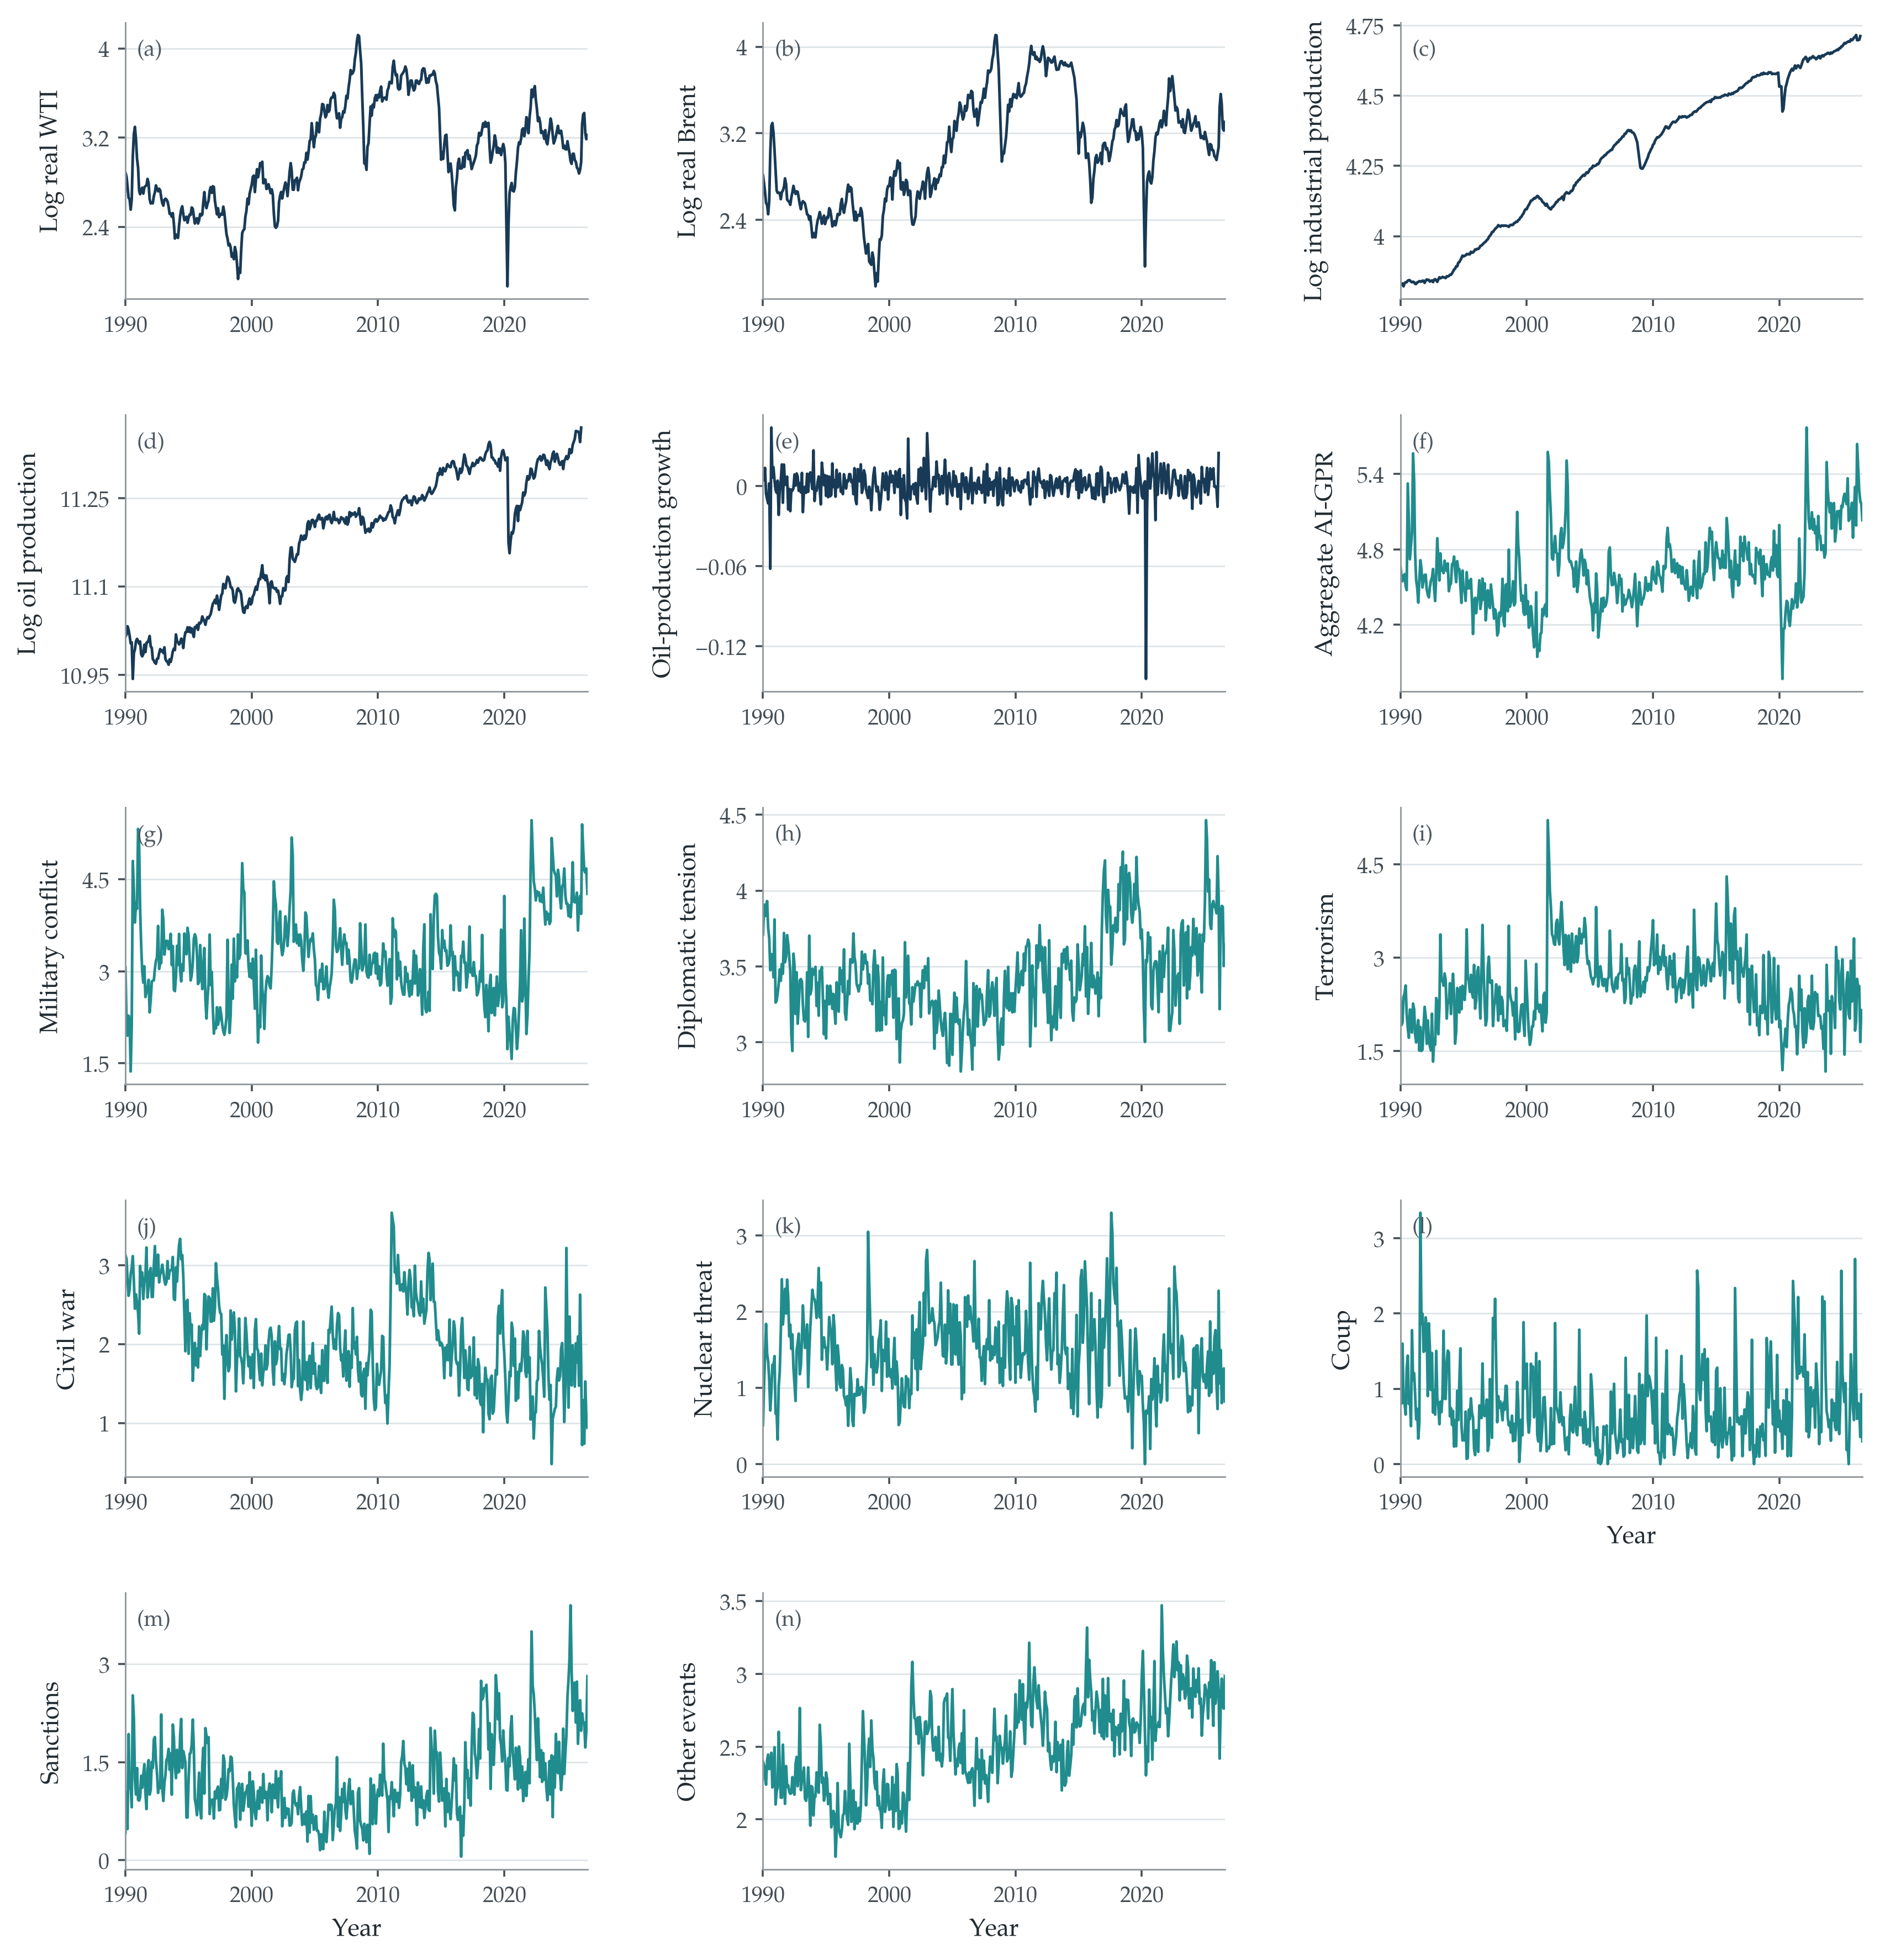

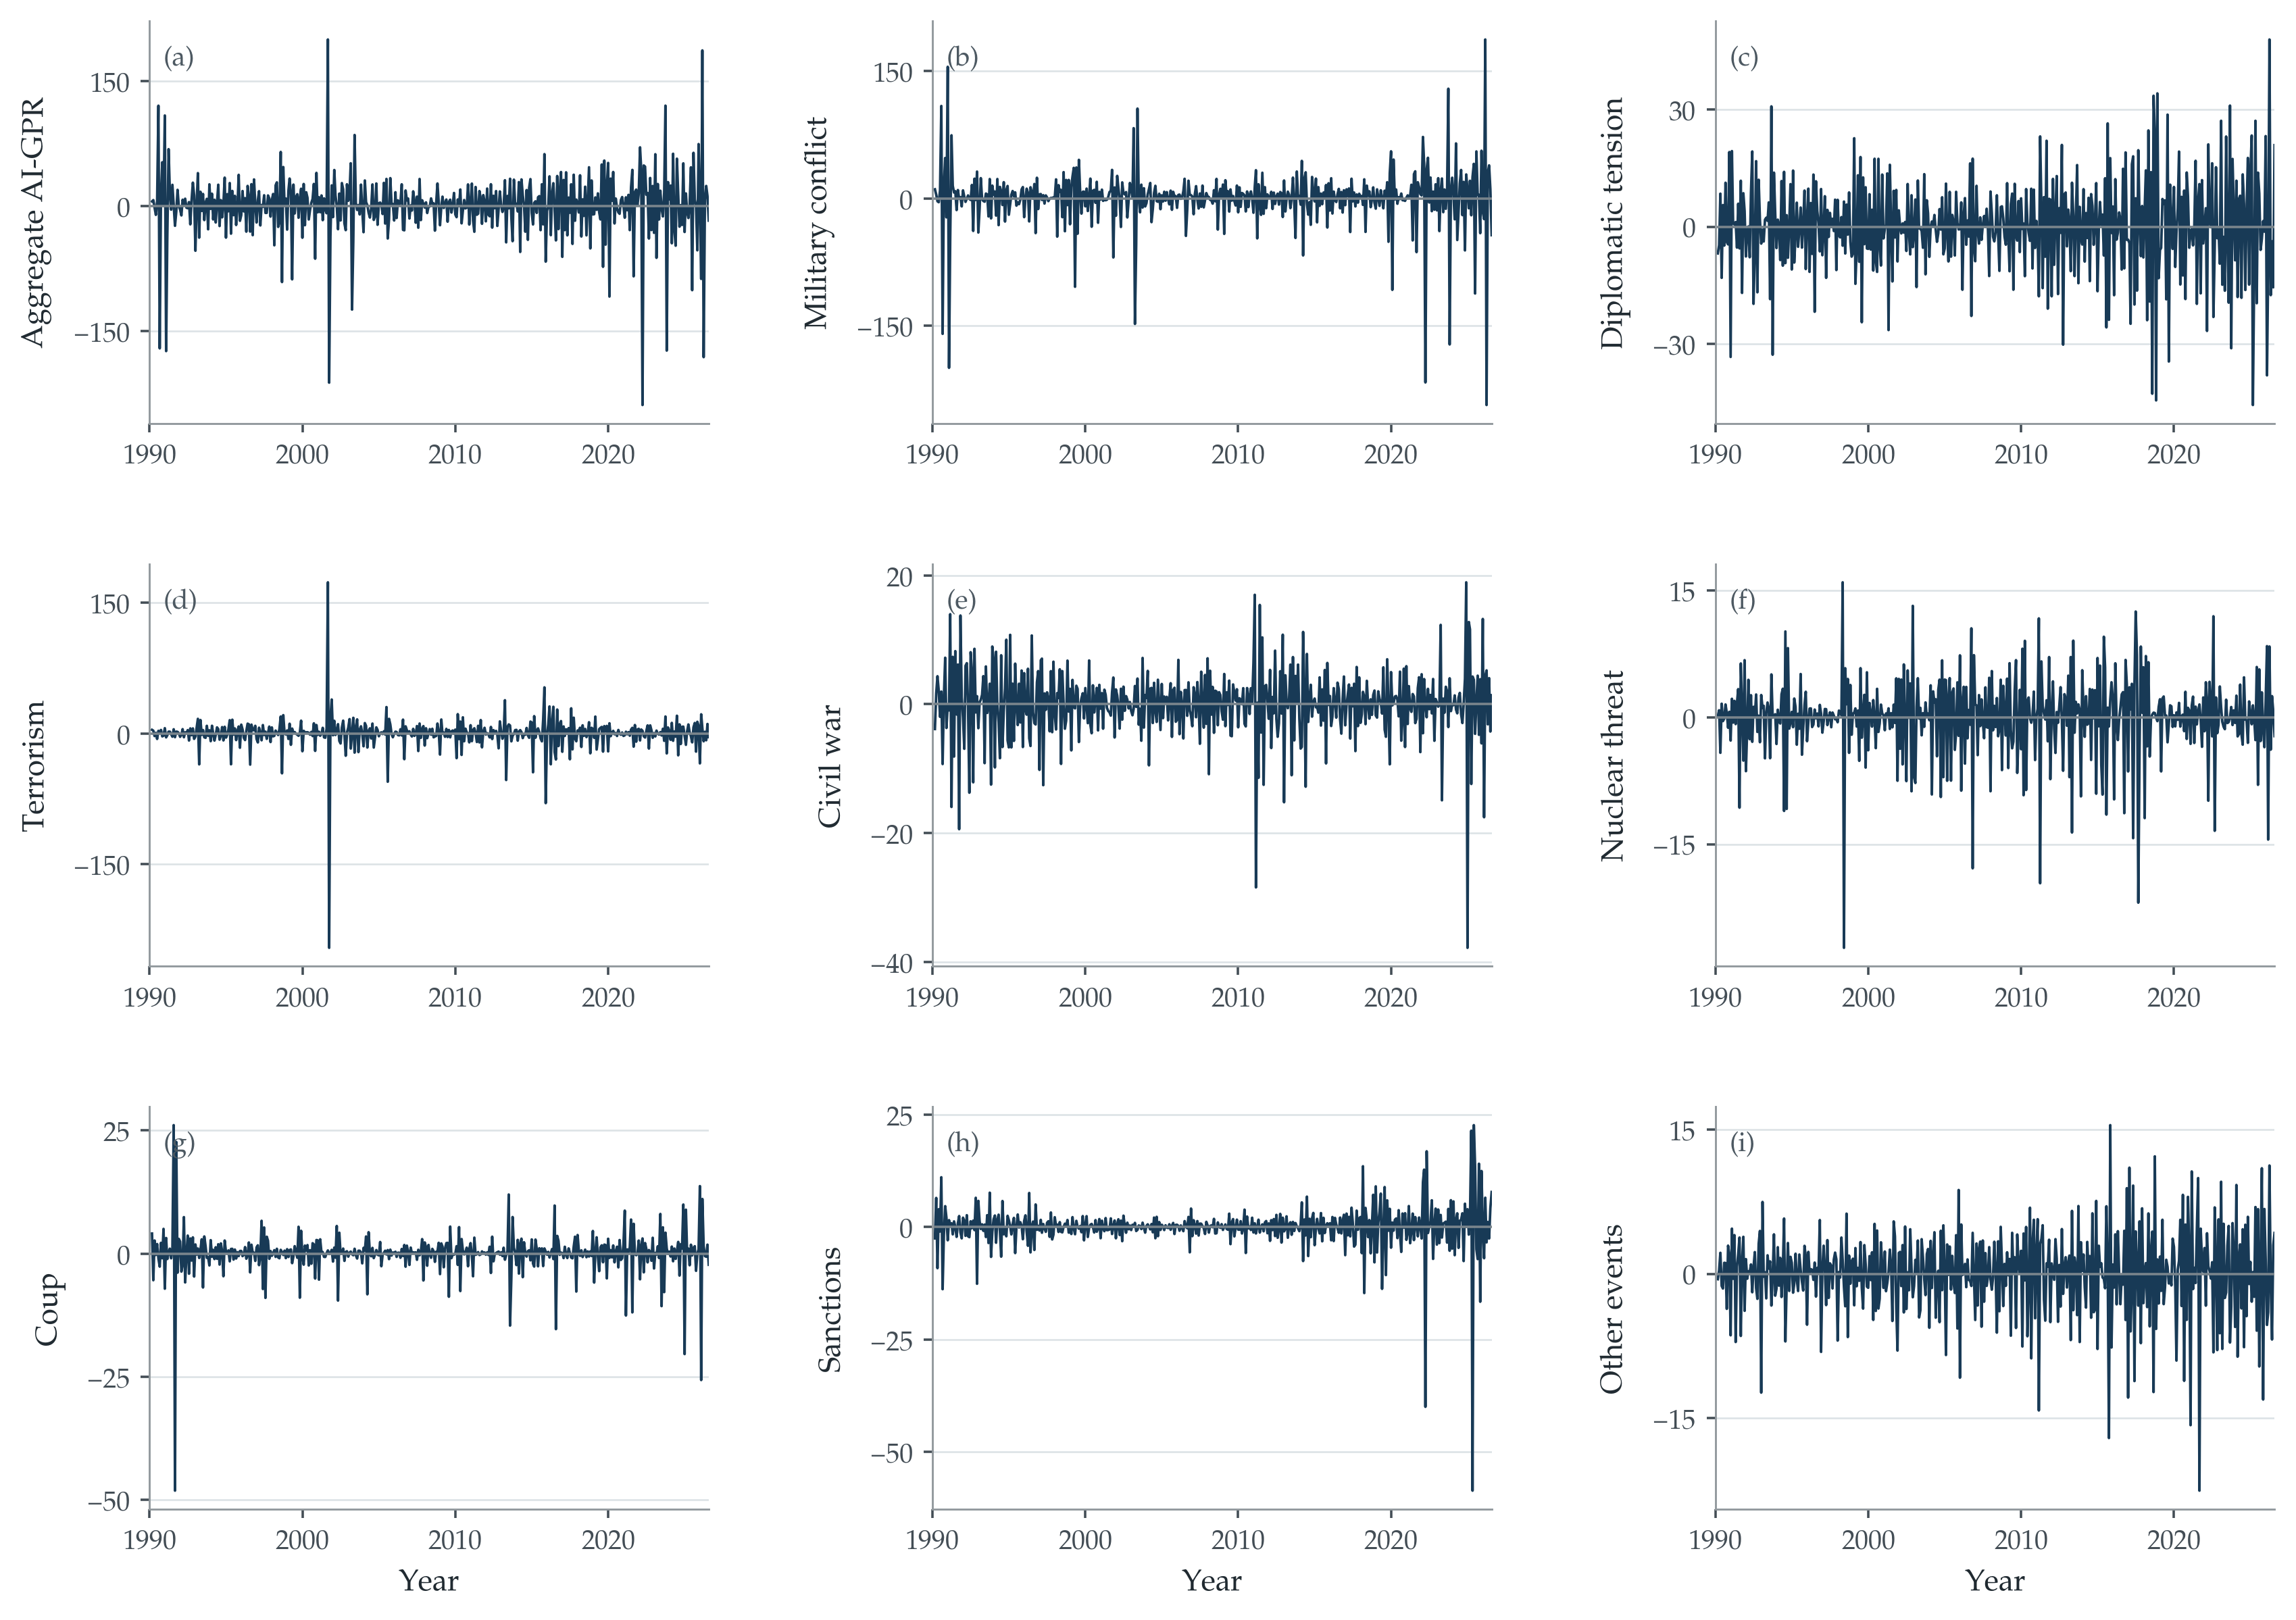

In [9]:
display(results["summary_statistics"])
captions = make_all_figures(data, results, FIGURES, EVENT_LABELS)
display(Image(filename=str(FIGURES / "fig01_all_variables.png")))
display(Image(filename=str(FIGURES / "fig02_turning_points.png")))

## 9 Separate-category local projections

Each curve answers how the oil-price level changes with the current log geopolitical index when its variation is selected by the raw turning-point instrument and the stated lag controls. Separate-category models do not condition on the other current event categories; the joint model below addresses their overlap. Brent is shown first, with WTI serving as the second benchmark.

Pointwise intervals answer a separate zero-coefficient question at each horizon. A sequence of individually significant points does not by itself establish significance of the whole response path. The joint path tests and simultaneous bands are reported separately.

,outcome,event,horizon,n,beta,hc3_se,hc3_p,hc1_p
0,lwti,gpr_ai,0,432,0.09399,0.04725,0.04670,0.03075
12,lwti,gpr_ai,12,425,-0.12329,0.07320,0.09214,0.08089
24,lwti,gpr_ai,24,413,-0.10404,0.08982,0.24673,0.22833
48,lwti,gpr_ai,48,389,-0.02132,0.14018,0.87911,0.86622
49,lwti,military_conflict,0,432,0.06512,0.02553,0.01075,0.00443
61,lwti,military_conflict,12,425,-0.00154,0.04846,0.97467,0.97251
73,lwti,military_conflict,24,413,0.00590,0.06310,0.92553,0.91998
97,lwti,military_conflict,48,389,0.04654,0.08393,0.57924,0.53418
98,lwti,diplomatic_tension,0,432,-0.01212,0.03119,0.69754,0.68344
110,lwti,diplomatic_tension,12,425,-0.19529,0.07533,0.00953,0.00811


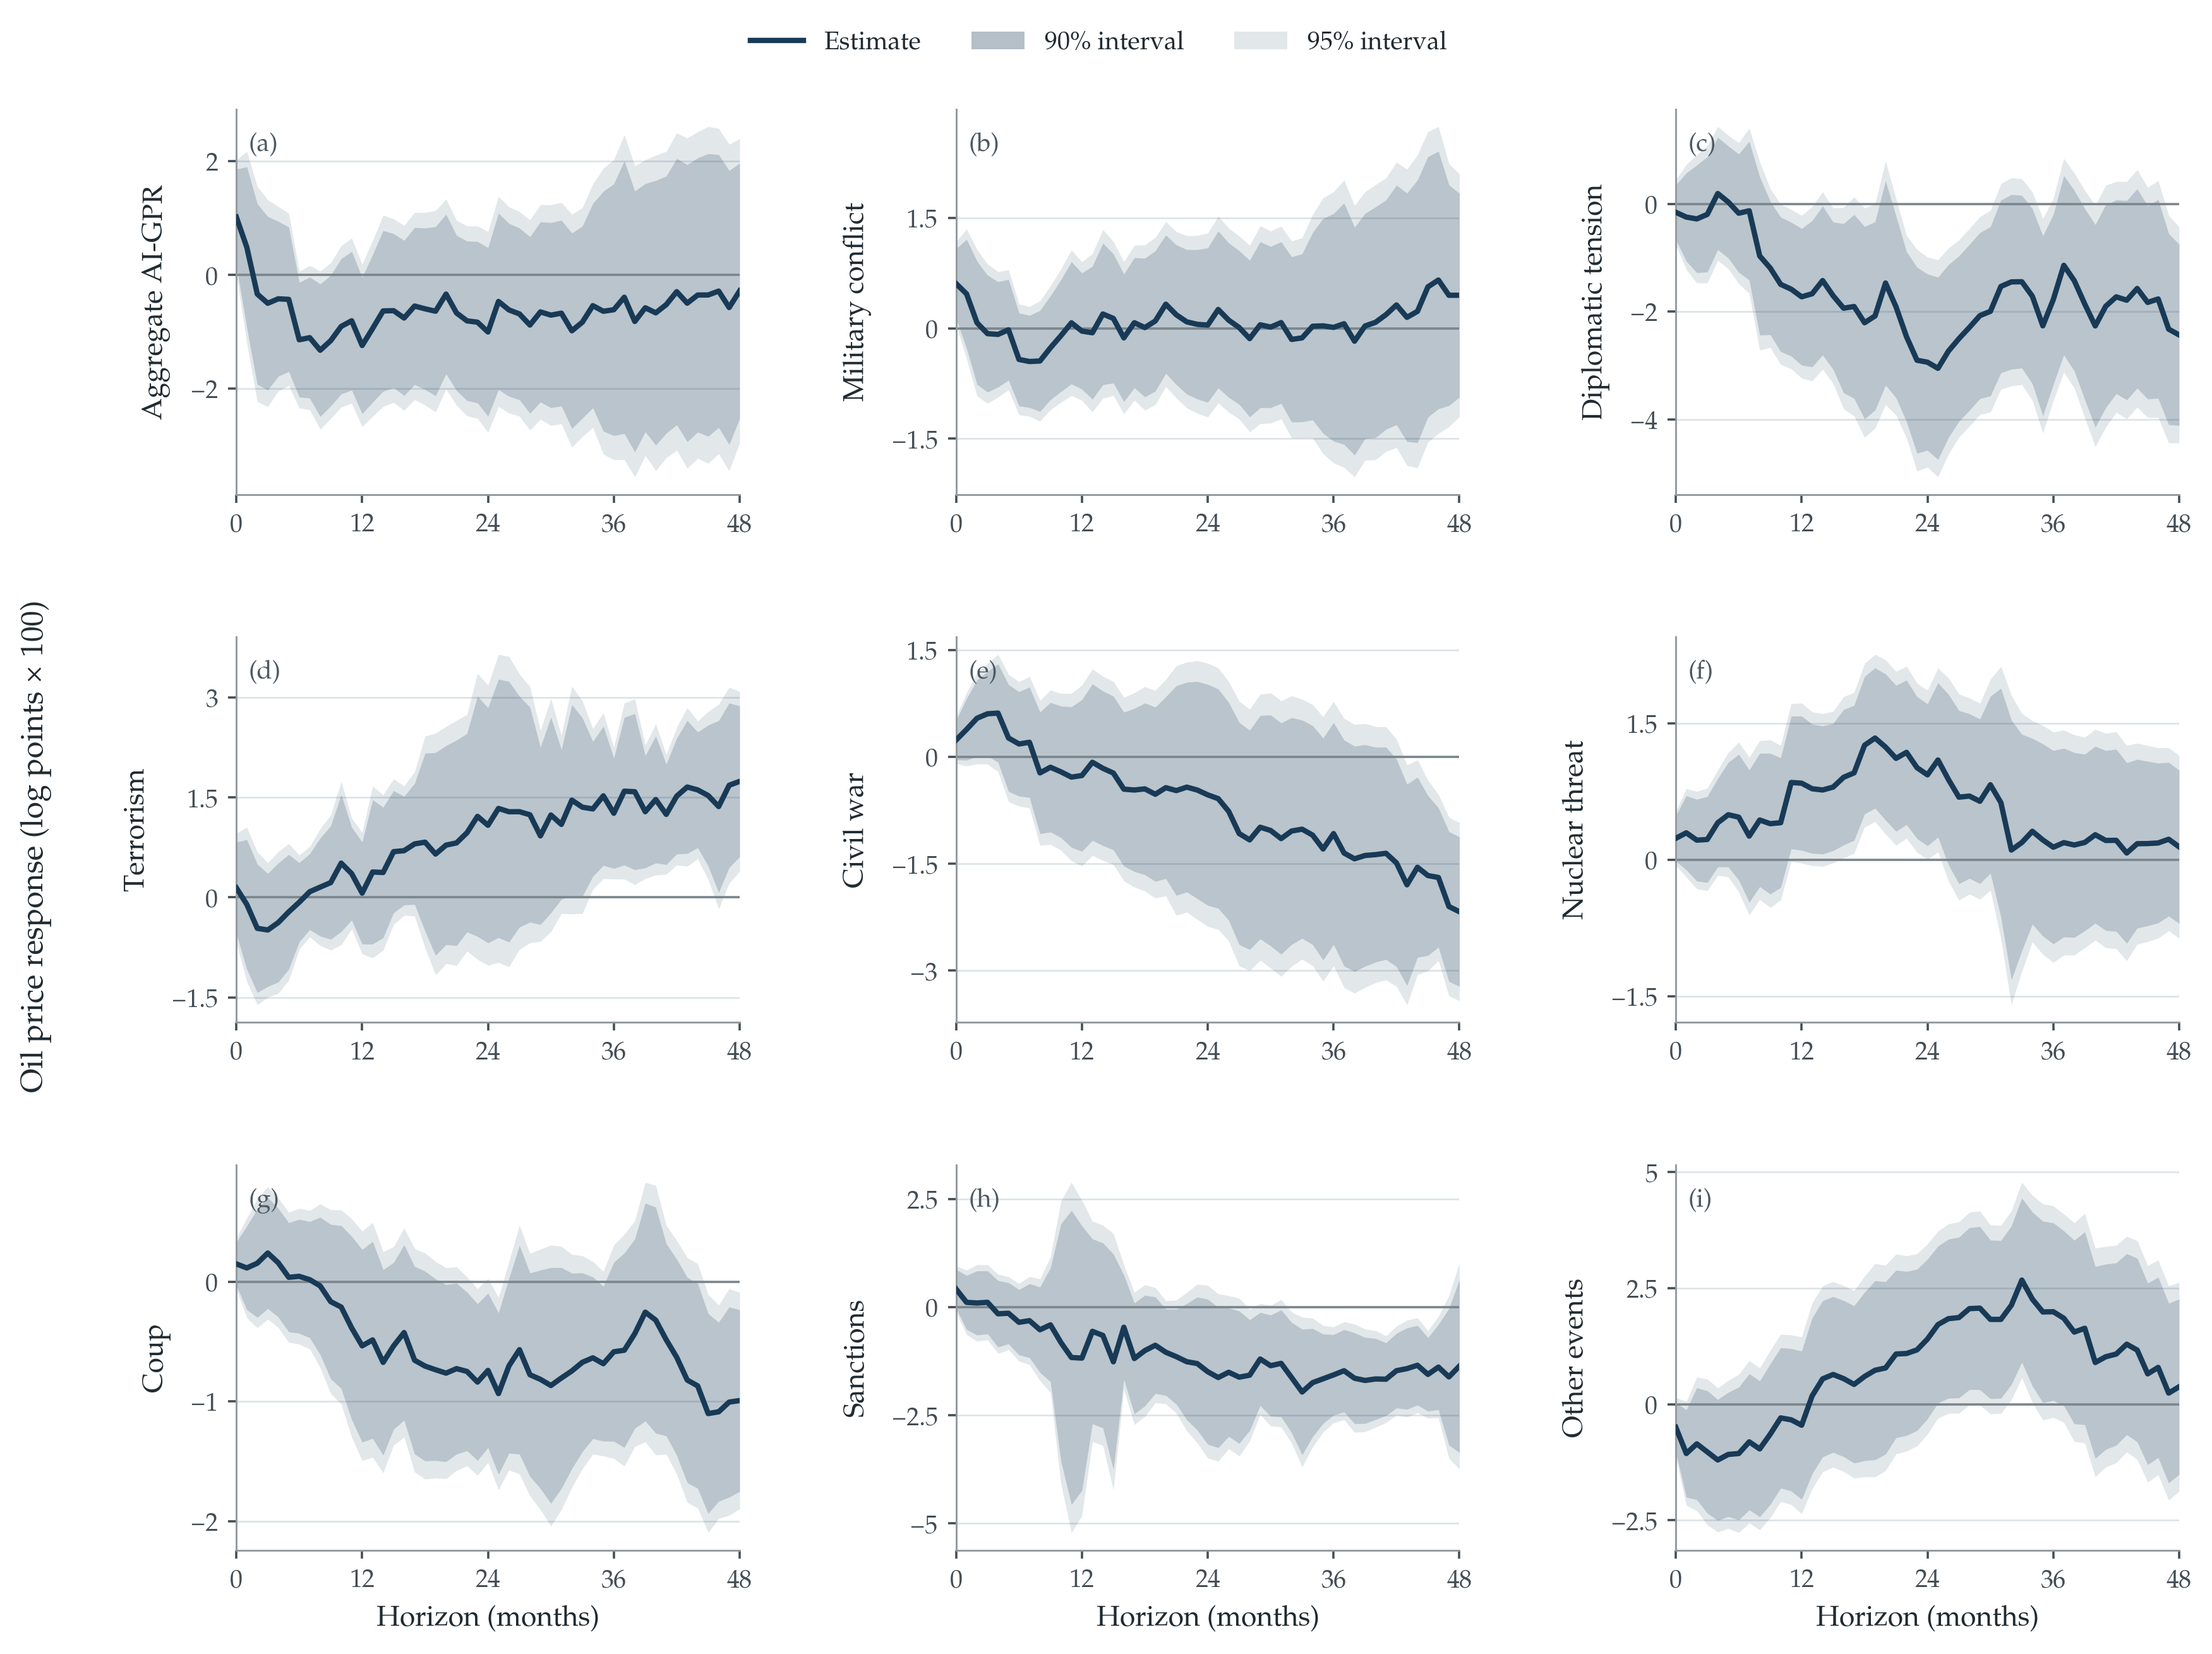

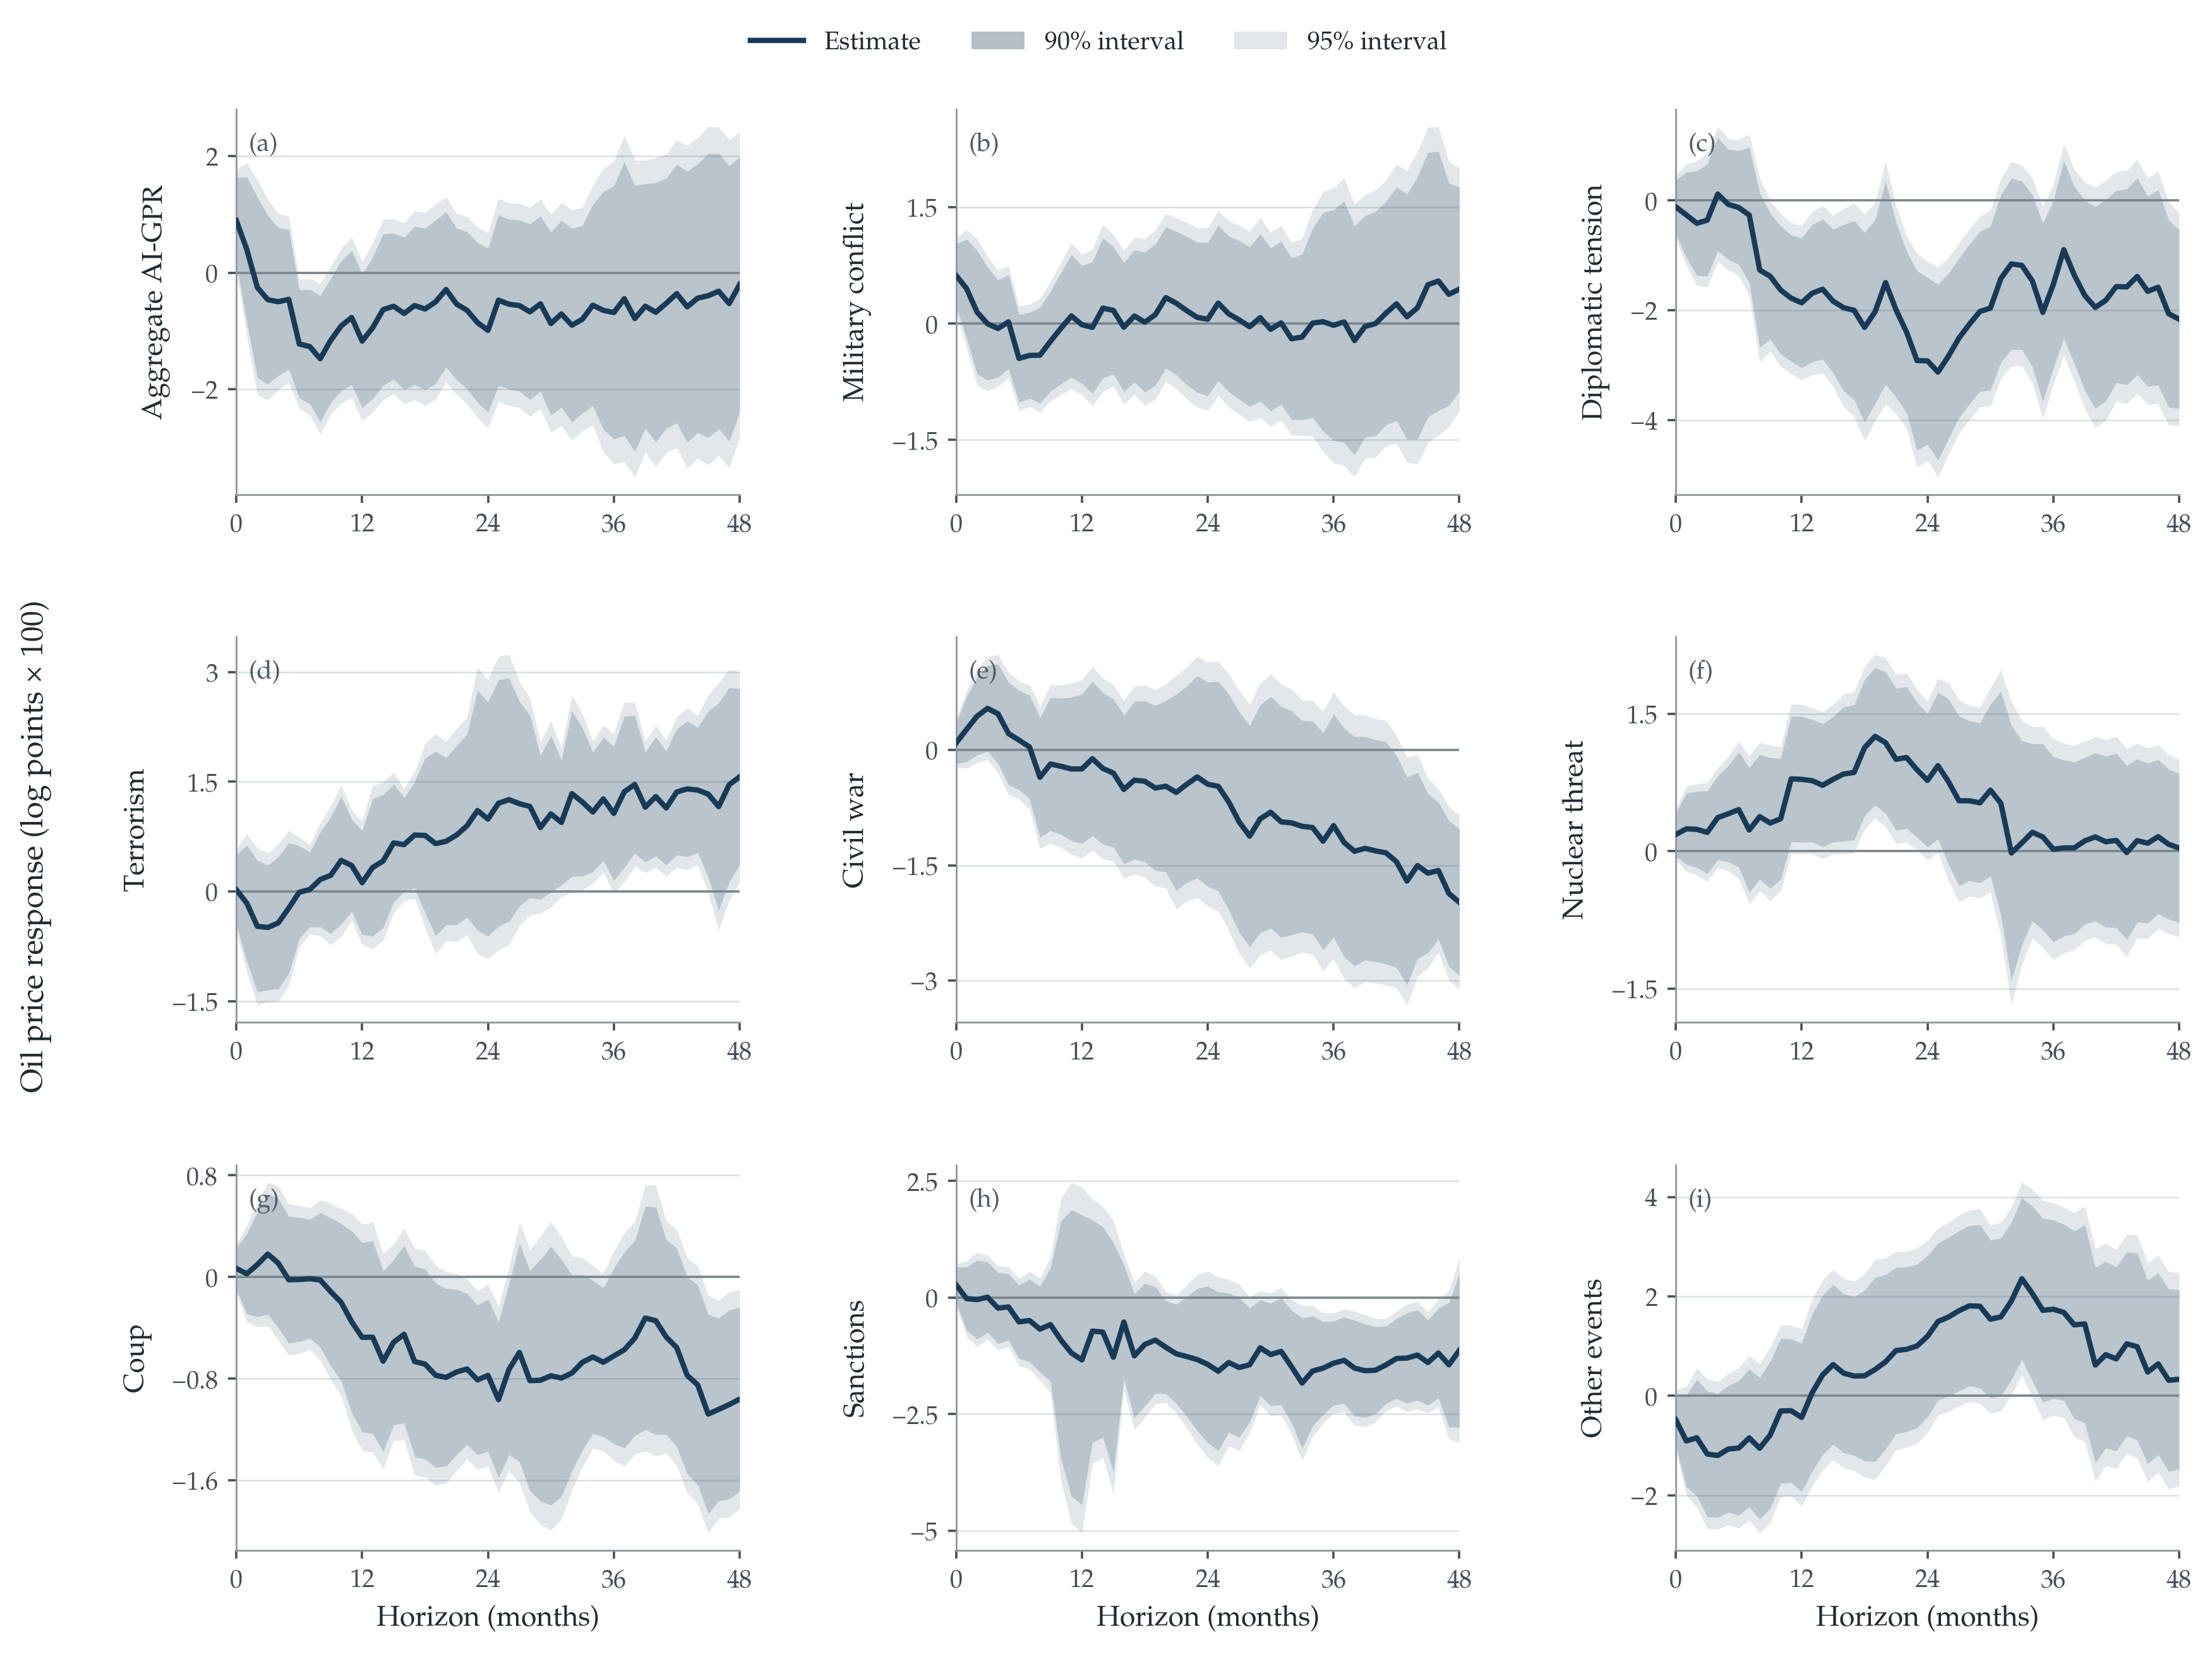

In [10]:
baseline = results["baseline_iv"]
display(baseline.loc[(baseline["model"] == "single") & baseline["horizon"].isin([0, 12, 24, 48]),
                     ["outcome", "event", "horizon", "n", "beta", "hc3_se", "hc3_p", "hc1_p"]])
display(Image(filename=str(FIGURES / "fig03_brent_separate_irfs.png")))
display(Image(filename=str(FIGURES / "fig03_wti_separate_irfs.png")))

## 10 The joint geopolitical specification and relevance diagnostics

The joint specification estimates military-conflict, diplomatic-tension, and nuclear-threat effects together. Each current treatment is instrumented by its own raw curvature series, with the three instruments entering every first-stage equation. Their lagged treatments are included together as controls.

The single-category first-stage statistic measures excluded-instrument relevance after controls. For the three-treatment model, `sw_conditional_first_stage.csv` implements the homoskedastic Sanderson–Windmeijer correction after conditionally instrumenting each exposure on the other two. Canonical correlations and the numerical cross-moment rank provide complementary geometry. The conditional first stages are reported because the principal specification contains three endogenous geopolitical categories.

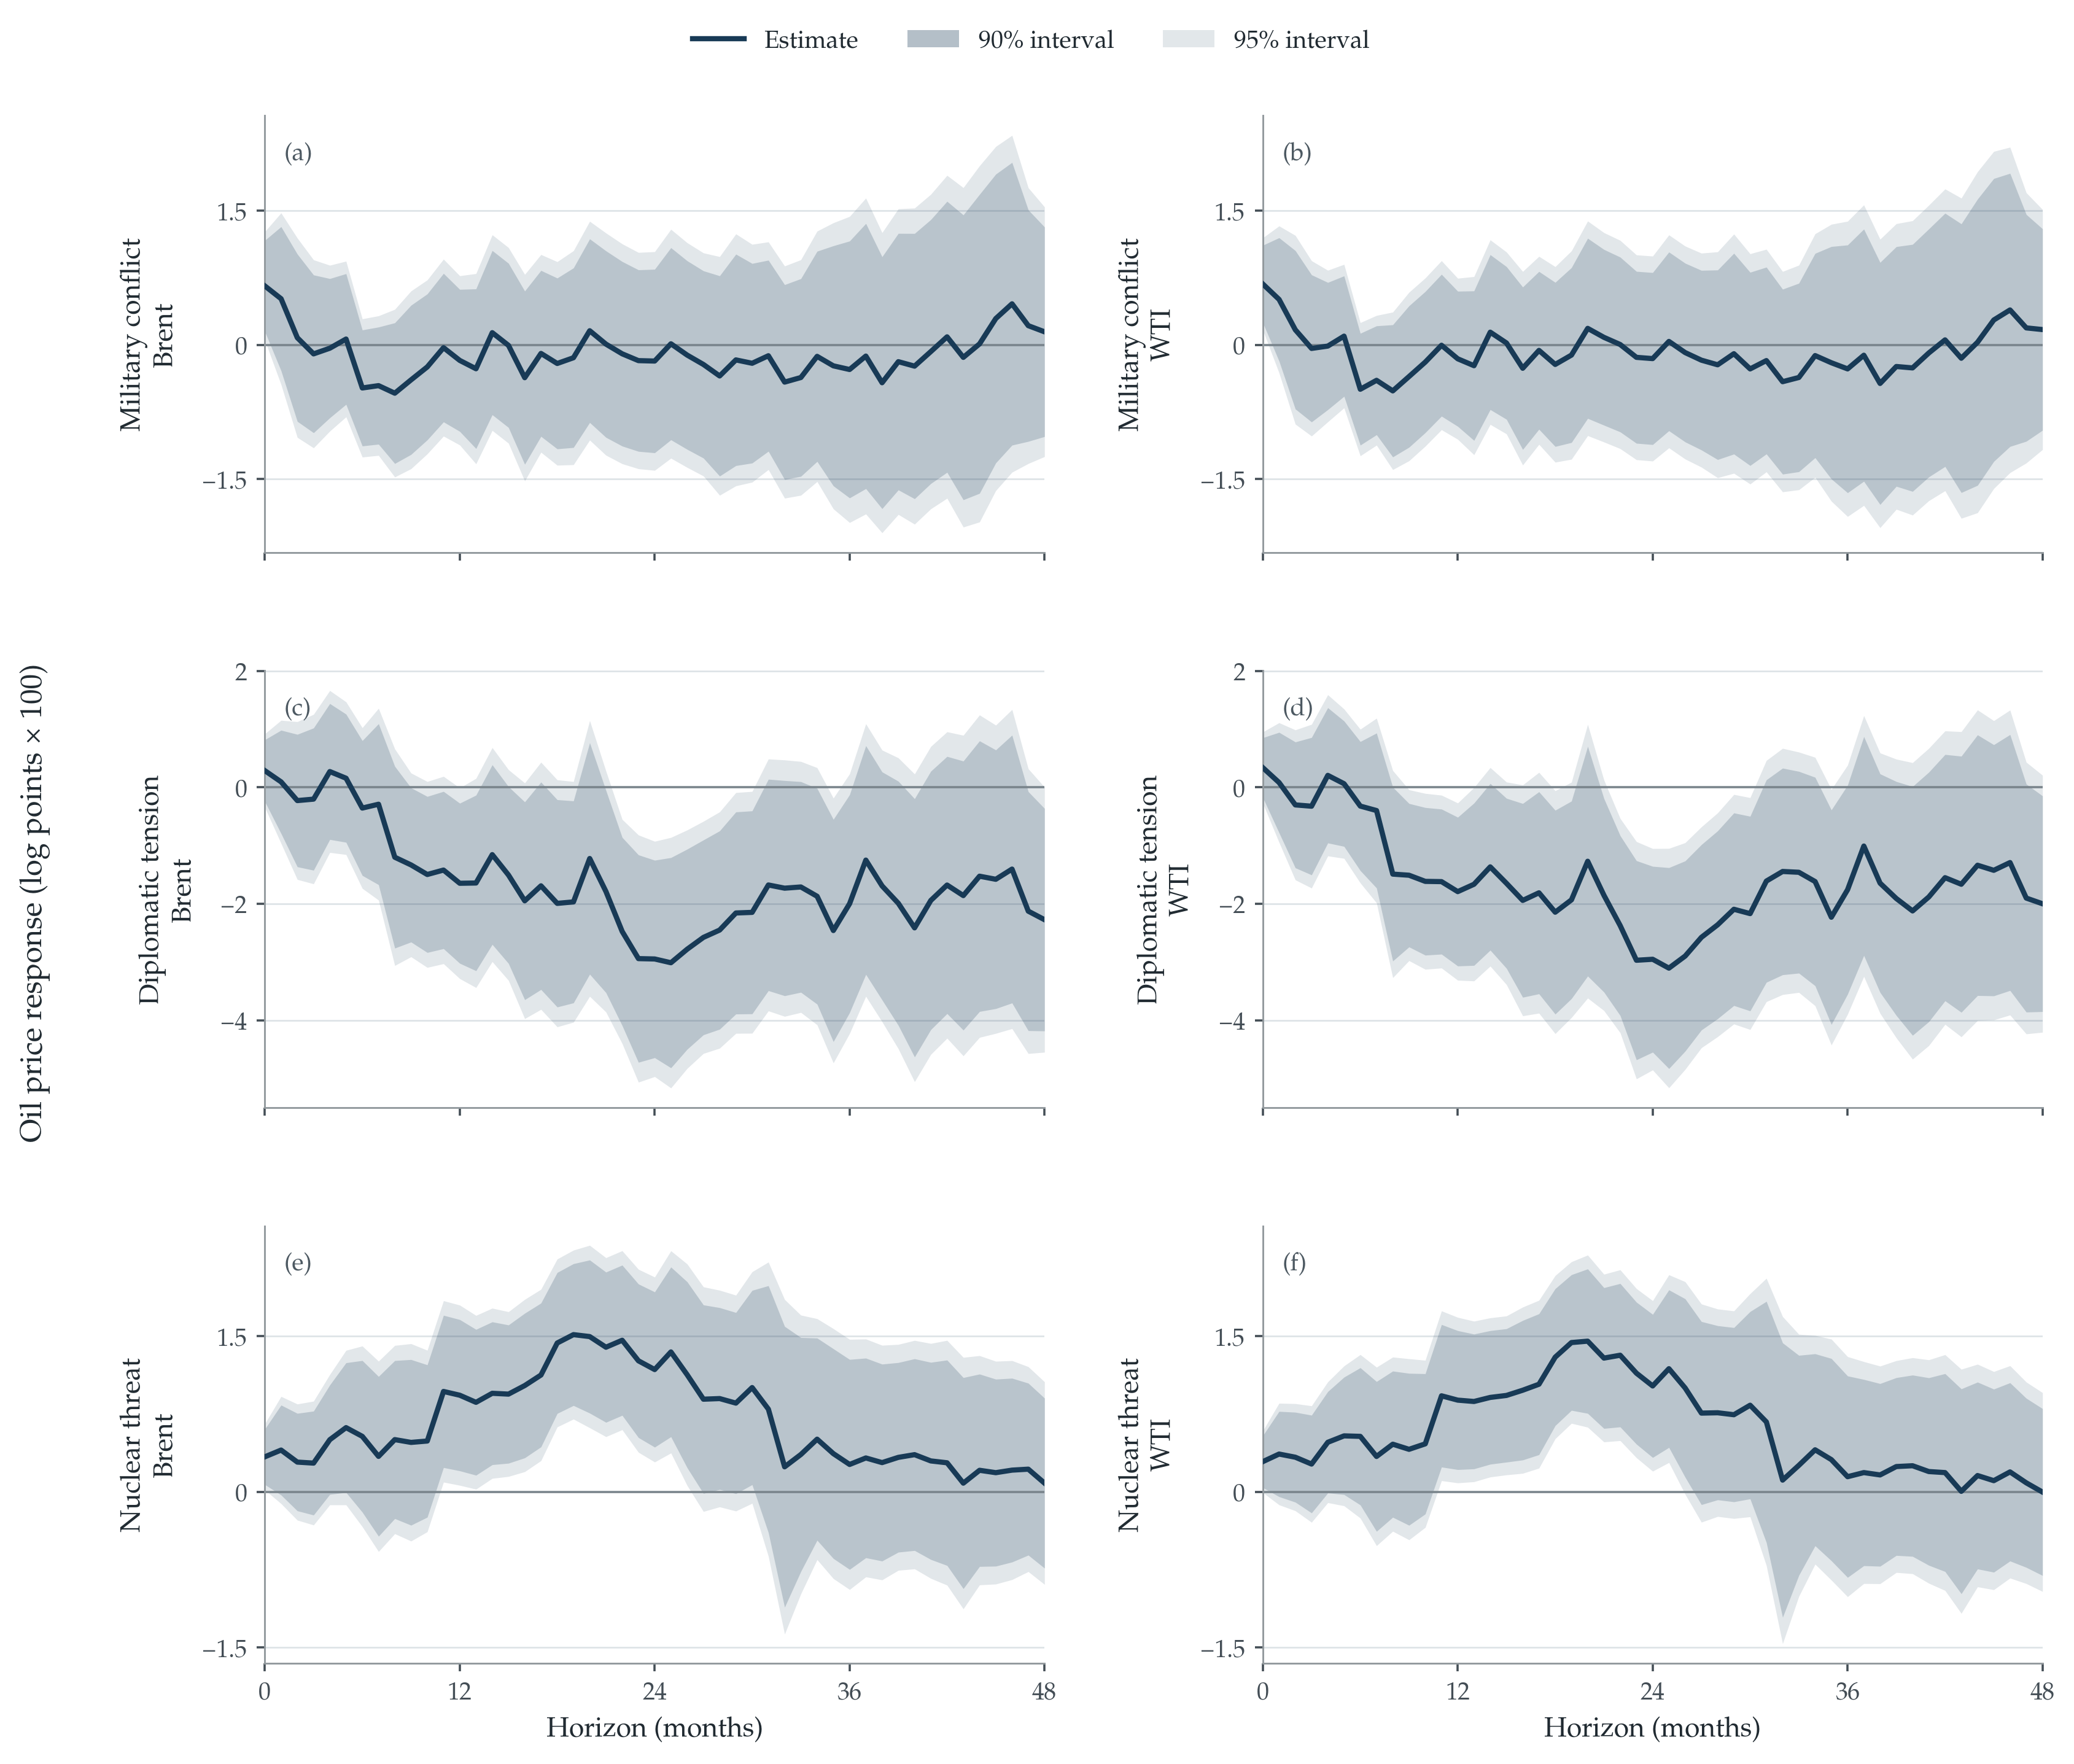

,model,outcome,horizon,n,event,partial_r2,excluded_instrument_wald_F_hc3,excluded_instrument_wald_chi2_hc3,relevance_p_value_hc3,excluded_instrument_wald_chi2,excluded_instrument_wald_F,excluded_instrument_df,relevance_p_value,diagnostic_type
0,single,lwti,0,432,gpr_ai,0.73645,145.65436,145.65436,0.00000,184.78788,184.78788,1,0.00000,single-instrument relevance
24,single,lwti,24,413,gpr_ai,0.72760,112.22917,112.22917,0.00000,147.89018,147.89018,1,0.00000,single-instrument relevance
48,single,lwti,48,389,gpr_ai,0.72081,81.97180,81.97180,0.00000,113.62798,113.62798,1,0.00000,single-instrument relevance
49,single,lwti,0,432,military_conflict,0.37005,32.81694,32.81694,0.00000,40.92529,40.92529,1,0.00000,single-instrument relevance
73,single,lwti,24,413,military_conflict,0.34667,22.33363,22.33363,0.00000,29.03551,29.03551,1,0.00000,single-instrument relevance
97,single,lwti,48,389,military_conflict,0.34493,15.61337,15.61337,0.00008,21.75754,21.75754,1,0.00000,single-instrument relevance
98,single,lwti,0,432,diplomatic_tension,0.76207,353.59183,353.59183,0.00000,381.29561,381.29561,1,0.00000,single-instrument relevance
122,single,lwti,24,413,diplomatic_tension,0.80173,383.53921,383.53921,0.00000,418.88936,418.88936,1,0.00000,single-instrument relevance
146,single,lwti,48,389,diplomatic_tension,0.78872,313.72604,313.72604,0.00000,346.10083,346.10083,1,0.00000,single-instrument relevance
147,single,lwti,0,432,terrorism,0.27379,2.63592,2.63592,0.10447,6.94923,6.94923,1,0.00839,single-instrument relevance


,model,outcome,horizon,n,events,minimum_canonical_correlation,ar_joint_zero_statistic_hc3,ar_joint_zero_p_value_hc3,maximum_canonical_correlation,canonical_correlation_ratio,first_stage_rank,ar_joint_zero_statistic,ar_df
441,joint,lwti,0,432,"military_conflict,diplomatic_tension,nuclear_threat",0.57728,10.99496,0.01175,0.87802,1.52096,3,20.70322,3
465,joint,lwti,24,413,"military_conflict,diplomatic_tension,nuclear_threat",0.57307,17.39021,0.00059,0.89697,1.56520,3,22.88486,3
489,joint,lwti,48,389,"military_conflict,diplomatic_tension,nuclear_threat",0.57106,4.37003,0.22418,0.89062,1.55961,3,4.12842,3
931,joint,lbrent,0,432,"military_conflict,diplomatic_tension,nuclear_threat",0.57631,9.62349,0.02205,0.87814,1.52371,3,14.39147,3
955,joint,lbrent,24,413,"military_conflict,diplomatic_tension,nuclear_threat",0.57146,16.49269,0.00090,0.89688,1.56946,3,22.24858,3
979,joint,lbrent,48,389,"military_conflict,diplomatic_tension,nuclear_threat",0.56930,5.16832,0.15988,0.89048,1.56417,3,4.95550,3


,model,outcome,horizon,n,event,sw_conditional_F,conditional_df,residual_df,raw_wald_F_all_instruments,excluded_instruments,endogenous_regressors,covariance_assumption
0,joint,lwti,0,432,military_conflict,210.35140,1,415,70.11713,3,3,homoskedastic Sanderson-Windmeijer correction
1,joint,lwti,0,432,diplomatic_tension,585.32822,1,415,195.10941,3,3,homoskedastic Sanderson-Windmeijer correction
2,joint,lwti,0,432,nuclear_threat,447.24272,1,415,149.08091,3,3,homoskedastic Sanderson-Windmeijer correction
36,joint,lwti,12,425,military_conflict,206.11543,1,408,68.70514,3,3,homoskedastic Sanderson-Windmeijer correction
37,joint,lwti,12,425,diplomatic_tension,646.77757,1,408,215.59252,3,3,homoskedastic Sanderson-Windmeijer correction
38,joint,lwti,12,425,nuclear_threat,460.79025,1,408,153.59675,3,3,homoskedastic Sanderson-Windmeijer correction
72,joint,lwti,24,413,military_conflict,195.17171,1,396,65.05724,3,3,homoskedastic Sanderson-Windmeijer correction
73,joint,lwti,24,413,diplomatic_tension,677.49109,1,396,225.83036,3,3,homoskedastic Sanderson-Windmeijer correction
74,joint,lwti,24,413,nuclear_threat,447.51087,1,396,149.17029,3,3,homoskedastic Sanderson-Windmeijer correction
144,joint,lwti,48,389,military_conflict,181.10431,1,372,60.36810,3,3,homoskedastic Sanderson-Windmeijer correction


In [11]:
display(Image(filename=str(FIGURES / "fig04_joint_irfs.png")))
display(results["first_stage"].loc[results["first_stage"]["horizon"].isin([0, 24, 48])])
display(results["joint_identification"].loc[
    (results["joint_identification"]["model"] == "joint") &
    results["joint_identification"]["horizon"].isin([0, 24, 48])])
display(results["sw_conditional_first_stage"].loc[
    results["sw_conditional_first_stage"]["horizon"].isin([0, 12, 24, 48])])

## 11 Anticipation estimates and their joint nulls

The table reports both permitted pre-event horizons, the fixed two-month instrument lead, and HC3 and HC1 inference. The two-coefficient joint tests allow for covariance between the $h=0$ and $h=1$ estimates. For the three-category joint specification, an additional six-coefficient test considers all three categories at both anticipation horizons. These are tests about prices **before** the future turning point, not responses after it.

In [12]:
display(results["anticipation"][["model", "outcome", "event", "horizon", "instrument_lead", "n",
                                  "beta", "hc3_p", "hc1_p"]])
display(results["anticipation_joint_tests"])

,model,outcome,event,horizon,instrument_lead,n,beta,hc3_p,hc1_p
0,single,lwti,gpr_ai,0,2,432,-0.00011,0.25101,0.22646
1,single,lwti,gpr_ai,1,2,432,-0.00022,0.32971,0.30086
2,single,lwti,military_conflict,0,2,432,-0.00010,0.38791,0.35838
3,single,lwti,military_conflict,1,2,432,-0.00030,0.26285,0.22176
4,single,lwti,diplomatic_tension,0,2,432,-0.00017,0.63053,0.62122
5,single,lwti,diplomatic_tension,1,2,432,0.00024,0.70292,0.69682
6,single,lwti,terrorism,0,2,432,-0.00015,0.38133,0.32587
7,single,lwti,terrorism,1,2,432,0.00008,0.77935,0.76703
8,single,lwti,civil_war,0,2,432,0.00092,0.11502,0.10606
9,single,lwti,civil_war,1,2,432,-0.00036,0.70505,0.69688


,model,outcome,event,null,covariance,wald_chi2,df,p_value
0,single,lwti,gpr_ai,theta_h0 = theta_h1 = 0,HC3,1.36727,2,0.50478
1,single,lwti,military_conflict,theta_h0 = theta_h1 = 0,HC3,1.27305,2,0.52913
2,single,lwti,diplomatic_tension,theta_h0 = theta_h1 = 0,HC3,1.33319,2,0.51345
3,single,lwti,terrorism,theta_h0 = theta_h1 = 0,HC3,3.59287,2,0.16589
4,single,lwti,civil_war,theta_h0 = theta_h1 = 0,HC3,8.91558,2,0.01159
5,single,lwti,nuclear_threat,theta_h0 = theta_h1 = 0,HC3,1.47081,2,0.47931
6,single,lwti,coup,theta_h0 = theta_h1 = 0,HC3,0.33802,2,0.84450
7,single,lwti,sanctions,theta_h0 = theta_h1 = 0,HC3,0.14155,2,0.93167
8,single,lwti,other,theta_h0 = theta_h1 = 0,HC3,1.21399,2,0.54499
9,joint,lwti,military_conflict,theta_h0 = theta_h1 = 0,HC3,1.54191,2,0.46257


## 12 Robustness exercises and what each one can establish

The exercises below address different concerns; they are not interchangeable tests of instrument validity.

| Exercise | Precisely what changes or is tested | Output |
|---|---|---|
| HC3 versus HC1 | Same augmented regression; different finite-sample heteroskedasticity corrections | `baseline_iv.csv` |
| Augmentation versus Newey–West | Three-price-lag HC3 versus two-price-lag NW6, with each model re-estimated on matched observations | `inference_comparison.csv` |
| Conventional HAC bandwidth sensitivity | Two-price-lag model with 4-, 12-, 24-, and 48-month Bartlett bandwidths | `hac_bandwidth.csv` |
| Equality across categories | Within the joint model, equality rather than separate significance is tested directly | `cross_category_equality.csv` |
| Joint path Wald test | Zero coefficients at the predeclared horizons 0, 6, 12, 24, 36, 48 | `path_wald.csv` |
| Simultaneous bands | Max-$t$ coverage over 49 horizons within one curve; Independent month multipliers baseline; 6/12-month blocks supplementary | `simultaneous_bands.csv` |
| Event-window omission | Re-estimate after removing origin months within one month of listed episodes | `event_drop.csv` |
| Historical origin-date splits | Estimate the long samples ending before 2012 and before 2019 | `origin_splits.csv` |
| Price-lag sensitivity | Two or four price lags, or three lags of every variable, on matched observations | `lag_sensitivity.csv` |
| Log-curvature contrast | Replace raw curvature with curvature of the logged treatment | `log_curvature.csv` |
| Current production control | Add current oil-production growth on a matched sample | `production_control.csv` |
| Cross-moment concentration | Inspect largest raw and residualized first-stage contributions | `leverage.csv` |

The event and split exercises refer to origin dates. At a fixed horizon, the two origin subsamples have disjoint outcome dates, but forecast-error windows can overlap across the cutoff, so their estimates are not treated as independent. Current production growth is a conditional control, not an identified oil-supply shock; including it can remove part of an economic transmission channel.

In [13]:
display(results["path_wald"])
band_summary = results["simultaneous_bands"].groupby(
    ["model", "outcome", "event", "block_length"], as_index=False).agg(
        Draws=("draws", "first"), Critical90=("critical90", "first"), Critical95=("critical95", "first"))
display(band_summary)
display(results["event_drop"][["outcome", "event", "horizon", "episode", "n_removed",
                                "baseline_beta", "beta", "sign_preserved"]])

,model,outcome,event,horizons,primary_covariance,primary_wald_chi2,primary_df,primary_p_value
0,single,lwti,military_conflict,"0,6,12,24,36,48",HC3,11.73981,6,0.06803
1,single,lwti,diplomatic_tension,"0,6,12,24,36,48",HC3,19.84164,6,0.00295
2,single,lwti,nuclear_threat,"0,6,12,24,36,48",HC3,6.68654,6,0.35081
3,joint,lwti,military_conflict,"0,6,12,24,36,48",HC3,9.83713,6,0.13168
4,joint,lwti,diplomatic_tension,"0,6,12,24,36,48",HC3,15.93744,6,0.01409
5,joint,lwti,nuclear_threat,"0,6,12,24,36,48",HC3,10.85858,6,0.09285
6,single,lbrent,military_conflict,"0,6,12,24,36,48",HC3,8.94343,6,0.17678
7,single,lbrent,diplomatic_tension,"0,6,12,24,36,48",HC3,18.19050,6,0.00577
8,single,lbrent,nuclear_threat,"0,6,12,24,36,48",HC3,8.04132,6,0.23509
9,joint,lbrent,military_conflict,"0,6,12,24,36,48",HC3,7.84211,6,0.24990


,model,outcome,event,block_length,Draws,Critical90,Critical95
0,joint,lbrent,diplomatic_tension,1,1999,2.67614,2.91160
1,joint,lbrent,diplomatic_tension,6,1999,2.70414,2.90195
2,joint,lbrent,diplomatic_tension,12,1999,2.66453,2.89935
3,joint,lbrent,military_conflict,1,1999,2.55580,2.78830
4,joint,lbrent,military_conflict,6,1999,2.68597,2.91602
5,joint,lbrent,military_conflict,12,1999,2.61023,2.87663
6,joint,lbrent,nuclear_threat,1,1999,2.63040,2.86250
7,joint,lbrent,nuclear_threat,6,1999,2.69821,2.91829
8,joint,lbrent,nuclear_threat,12,1999,2.68755,2.93402
9,joint,lwti,diplomatic_tension,1,1999,2.67057,2.87764


,outcome,event,horizon,episode,n_removed,baseline_beta,beta,sign_preserved
0,lwti,military_conflict,0,Iraq invades Kuwait,3,0.06512,0.06014,True
1,lwti,military_conflict,0,Gulf War air campaign,3,0.06512,0.06151,True
2,lwti,military_conflict,0,Indian and Pakistani nuclear tests,3,0.06512,0.06608,True
3,lwti,military_conflict,0,September 11 attacks,3,0.06512,0.07077,True
4,lwti,military_conflict,0,Invasion of Iraq,3,0.06512,0.06450,True
5,lwti,military_conflict,0,North Korean nuclear test,3,0.06512,0.06501,True
6,lwti,military_conflict,0,Libyan uprising,3,0.06512,0.06462,True
7,lwti,military_conflict,0,Egyptian military takeover,3,0.06512,0.06574,True
8,lwti,military_conflict,0,Paris attacks,3,0.06512,0.06502,True
9,lwti,military_conflict,0,North Korean missile escalation,3,0.06512,0.06504,True


### Direct tests of heterogeneity and alternative conventional inference

An effect being individually significant while another is not does not establish that the two effects differ. `cross_category_equality.csv` therefore reports explicit within-joint-model restrictions, both at individual horizons and jointly across the predeclared horizon grid. Their covariance includes cross-category and, for path tests, cross-horizon dependence. These are tests of equality for the specified normalized log-index changes, not equal physical or historical events.

The Newey–West comparison is estimated separately: two price lags with a six-month Bartlett bandwidth, versus the augmented three-price-lag HC3 model on the same observations. Its coefficient and standard error are exported together. A further grid varies the conventional model bandwidth over 4, 12, 24, and 48 months. It never changes the baseline HC3 bands.

In [14]:
display(results["cross_category_equality"])
display(results["inference_comparison"].query("horizon in [0,12,24,48]"))
display(results["hac_bandwidth"])

,outcome,test,horizon,scope,covariance,difference,wald_chi2,df,p_value
0,lwti,all_three_equal,0,pointwise,HC3,NaN,2.09574,2,0.35068
1,lwti,all_three_equal,0,pointwise,HC1,NaN,2.60037,2,0.27248
4,lwti,military_minus_diplomatic,0,pointwise,HC3,0.03593,1.12315,1,0.28924
5,lwti,military_minus_diplomatic,0,pointwise,HC1,0.03593,1.32686,1,0.24936
8,lwti,military_minus_nuclear,0,pointwise,HC3,0.04089,1.90801,1,0.16718
9,lwti,military_minus_nuclear,0,pointwise,HC1,0.04089,2.33849,1,0.12621
12,lwti,diplomatic_minus_nuclear,0,pointwise,HC3,0.00496,0.02385,1,0.87727
13,lwti,diplomatic_minus_nuclear,0,pointwise,HC1,0.00496,0.02653,1,0.87061
16,lwti,all_three_equal,12,pointwise,HC3,NaN,9.67041,2,0.00795
17,lwti,all_three_equal,12,pointwise,HC1,NaN,10.41099,2,0.00549


,model,outcome,event,horizon,n,augmented_price_lags,conventional_price_lags,augmented_beta,augmented_hc3_se,conventional_beta,conventional_hac6_se,comparison
0,single,lwti,military_conflict,0,432,3,2,0.06512,0.02553,0.06628,0.01817,Matched observations; distinct regressions and covariance estimators
12,single,lwti,military_conflict,12,425,3,2,-0.00154,0.04846,0.00266,0.03584,Matched observations; distinct regressions and covariance estimators
24,single,lwti,military_conflict,24,413,3,2,0.00590,0.06310,0.01135,0.04621,Matched observations; distinct regressions and covariance estimators
48,single,lwti,military_conflict,48,389,3,2,0.04654,0.08393,0.04890,0.04958,Matched observations; distinct regressions and covariance estimators
49,single,lwti,diplomatic_tension,0,432,3,2,-0.01212,0.03119,-0.01348,0.03494,Matched observations; distinct regressions and covariance estimators
61,single,lwti,diplomatic_tension,12,425,3,2,-0.19529,0.07533,-0.19896,0.06590,Matched observations; distinct regressions and covariance estimators
73,single,lwti,diplomatic_tension,24,413,3,2,-0.30642,0.09695,-0.30969,0.07752,Matched observations; distinct regressions and covariance estimators
97,single,lwti,diplomatic_tension,48,389,3,2,-0.22666,0.10381,-0.22723,0.09537,Matched observations; distinct regressions and covariance estimators
98,single,lwti,nuclear_threat,0,432,3,2,0.01909,0.01507,0.01966,0.01131,Matched observations; distinct regressions and covariance estimators
110,single,lwti,nuclear_threat,12,425,3,2,0.08221,0.04382,0.08477,0.03665,Matched observations; distinct regressions and covariance estimators


,model,outcome,event,horizon,n,hac_lag,beta,hac_se,hac_p,hac_95_low,hac_95_high
0,single,lwti,military_conflict,0,432,4,0.06628,0.01870,0.00039,0.02963,0.10294
1,single,lwti,military_conflict,0,432,12,0.06628,0.01771,0.00018,0.03158,0.10099
2,single,lwti,military_conflict,0,432,24,0.06628,0.01636,0.00005,0.03422,0.09835
3,single,lwti,military_conflict,0,432,48,0.06628,0.01457,0.00001,0.03773,0.09484
4,single,lwti,military_conflict,12,425,4,0.00266,0.03570,0.94050,-0.06731,0.07264
5,single,lwti,military_conflict,12,425,12,0.00266,0.03973,0.94653,-0.07521,0.08054
6,single,lwti,military_conflict,12,425,24,0.00266,0.04416,0.95189,-0.08390,0.08923
7,single,lwti,military_conflict,12,425,48,0.00266,0.05066,0.95805,-0.09662,0.10195
8,single,lwti,military_conflict,24,413,4,0.01135,0.04513,0.80137,-0.07709,0.09980
9,single,lwti,military_conflict,24,413,12,0.01135,0.04888,0.81636,-0.08446,0.10716


### Demand and physical-supply channel evidence

The same three-treatment joint design is re-estimated with log world industrial production and global oil-production growth as outcomes. Each outcome receives three lags, while the other fundamentals, real Brent, and the geopolitical treatments receive two. A fall in world activity accompanying a diplomatic turning point would support a demand-side interpretation; a fall in oil-production growth would support a physical-supply interpretation. These are outcome responses under the same instruments, not a formal mediation decomposition, because the oil-price equation is not conditioned on an independently identified mediator.

,outcome,event,horizon,n,beta,hc3_se,hc3_p
0,lwip,military_conflict,0,432,-0.00170,0.00210,0.41947
1,lwip,diplomatic_tension,0,432,0.00269,0.00309,0.38399
2,lwip,nuclear_threat,0,432,-0.00022,0.00100,0.82897
18,lwip,military_conflict,6,429,-0.00353,0.00390,0.36481
19,lwip,diplomatic_tension,6,429,-0.00265,0.00725,0.71427
20,lwip,nuclear_threat,6,429,0.00109,0.00313,0.72781
36,lwip,military_conflict,12,423,-0.00028,0.00428,0.94728
37,lwip,diplomatic_tension,12,423,-0.00621,0.00918,0.49884
38,lwip,nuclear_threat,12,423,0.00608,0.00476,0.20117
72,lwip,military_conflict,24,411,-0.00133,0.00575,0.81662


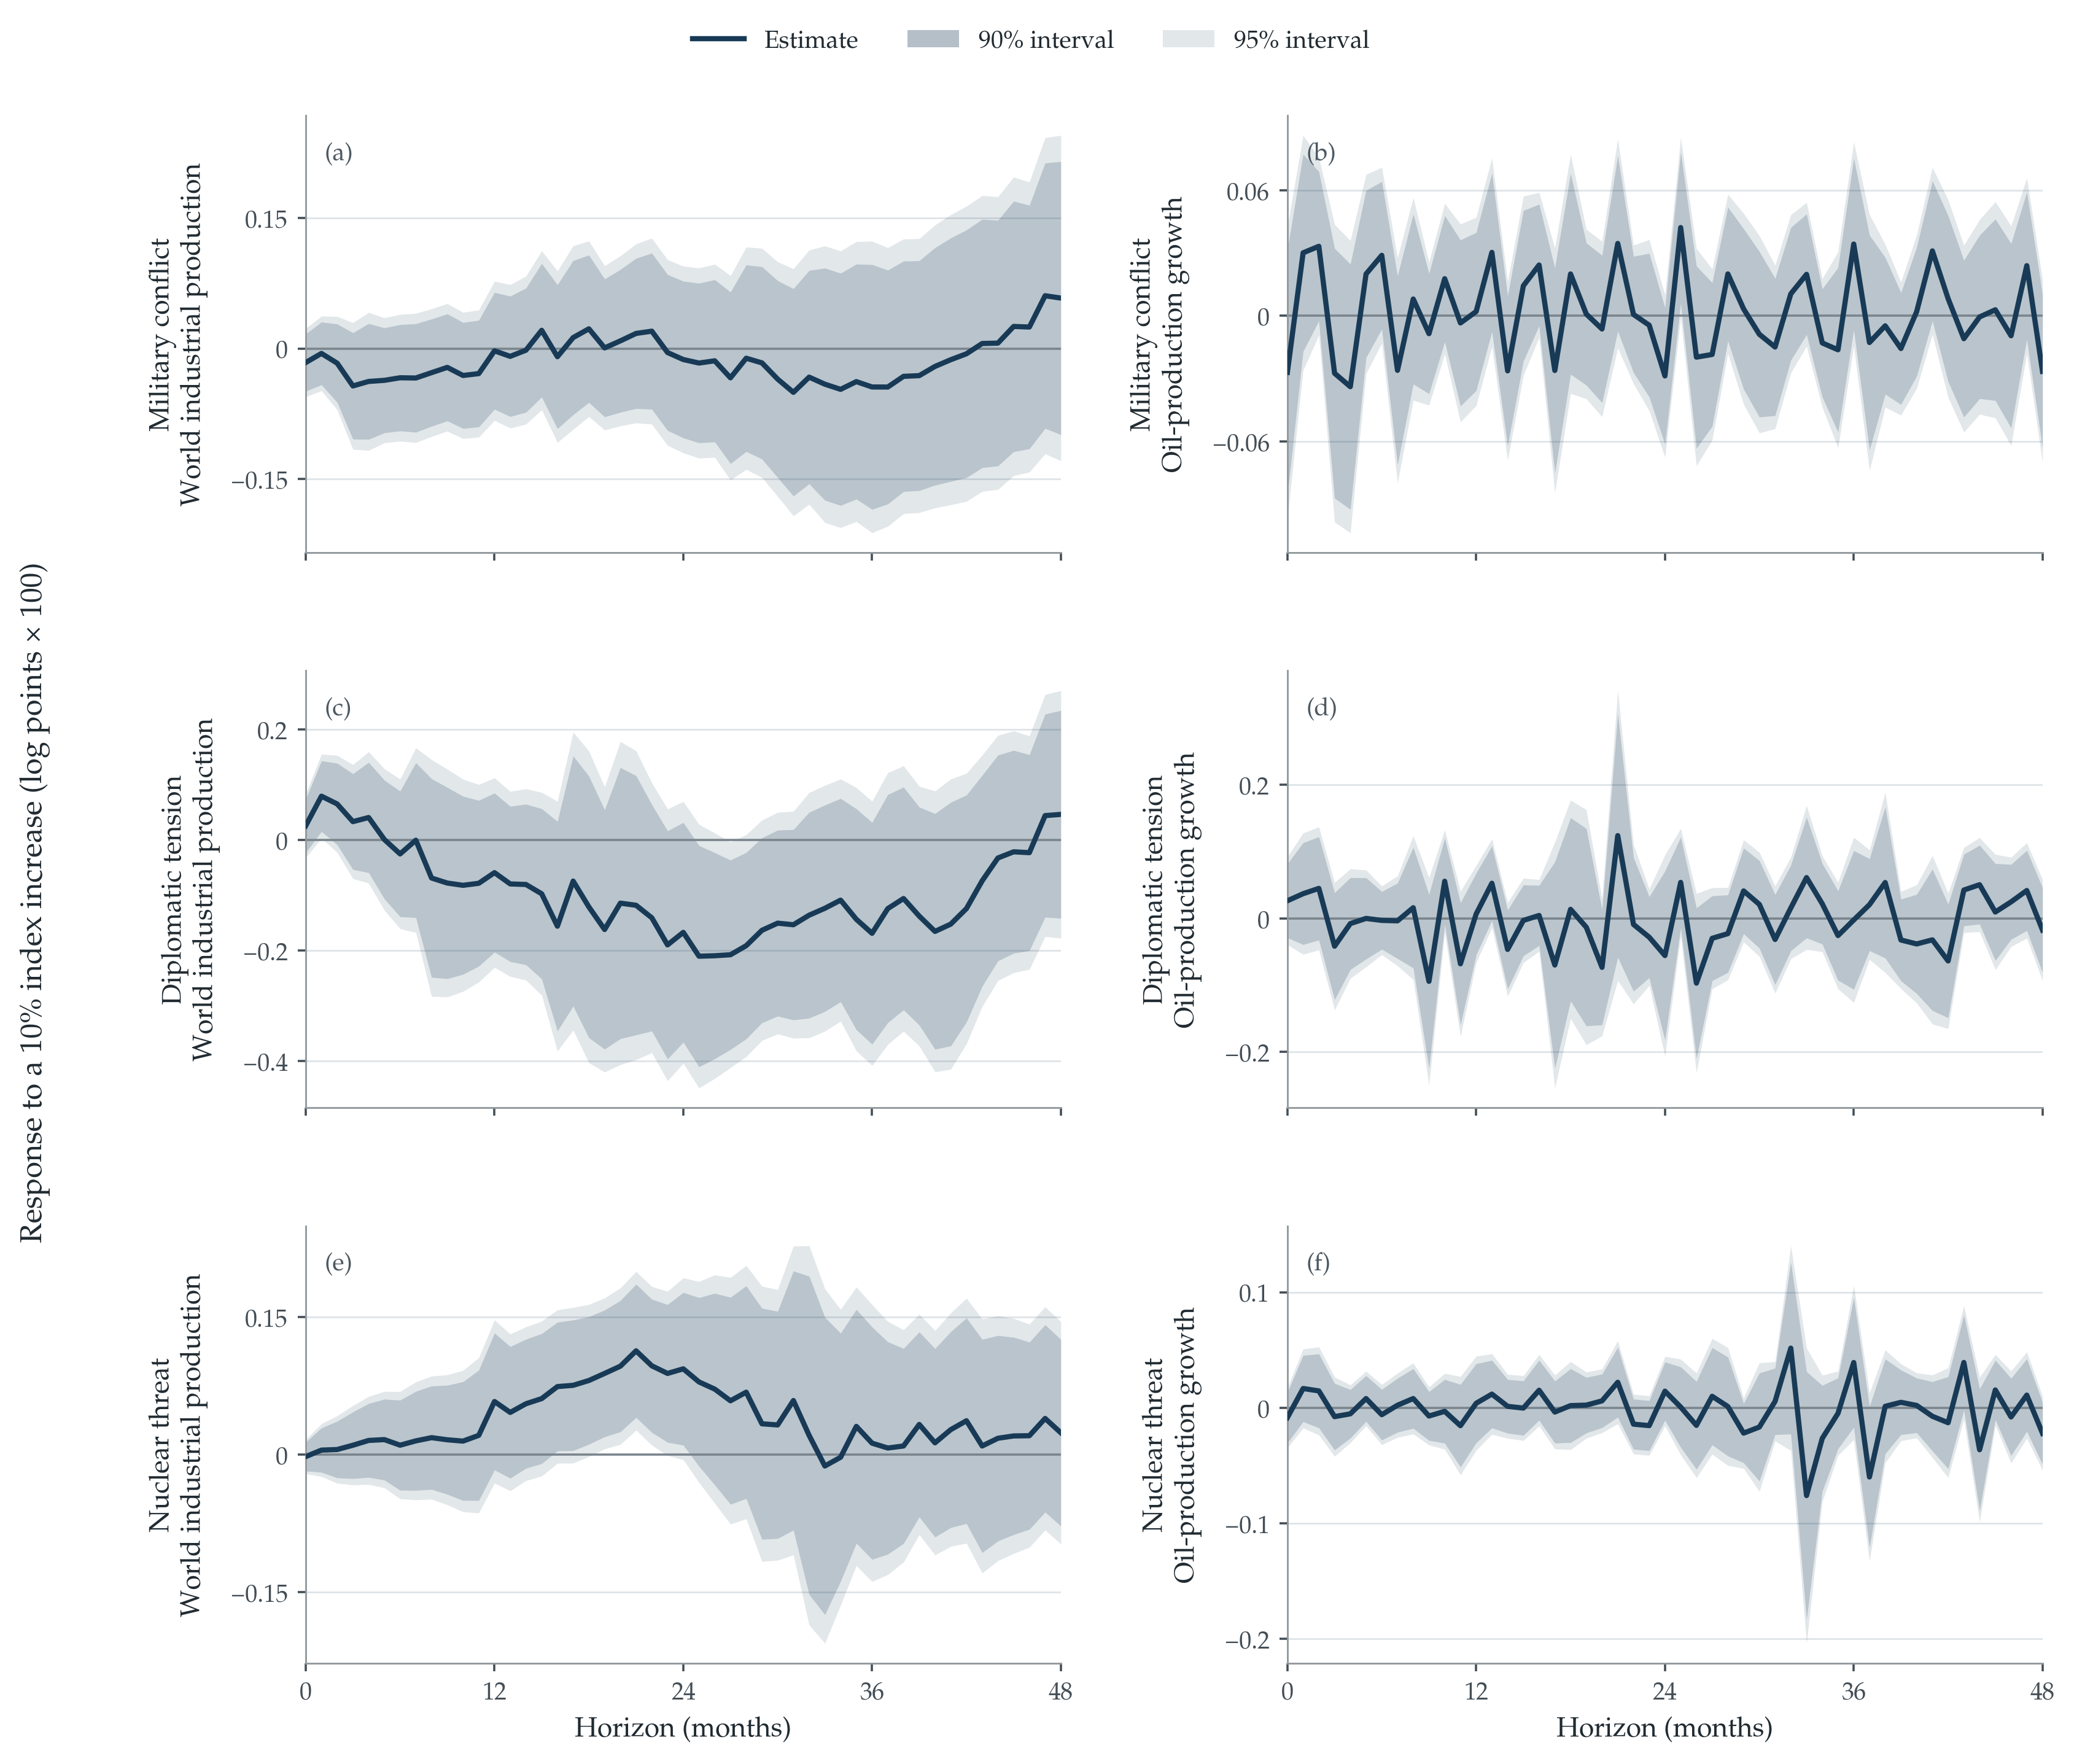

In [15]:
display(results["mechanism_iv"].loc[
    results["mechanism_iv"]["horizon"].isin([0, 6, 12, 24, 36, 48]),
    ["outcome", "event", "horizon", "n", "beta", "hc3_se", "hc3_p"]])
display(Image(filename=str(FIGURES / "figS01_mechanism_irfs.png")))

### Simultaneous uncertainty and robustness interpretation

The simultaneous bands use fixed-design multipliers on **HC3 influence rows**, not a bootstrap that re-estimates models on resampled events. The baseline uses independent Rademacher multipliers for every month (`block_length=1`). Supplementary block lengths of six and twelve months allow multipliers to be shared within contiguous calendar blocks, with a random block origin in each draw. Missing observation scores are zero-filled on the complete calendar. Each curve is adjusted across its 49 horizons; the procedure does not provide family-wise coverage across all event types and both oil prices together.

The origin splits and event omissions are descriptive sensitivity exercises, not formal evidence that coefficients differ. The treatment and control transformations are always computed before sample restrictions, preserving the calendar meaning of each lag and lead.

In [16]:
display(results["origin_splits"].loc[
    results["origin_splits"]["specification"].isin(["pre_2012", "pre_2019"]),
    ["outcome", "event", "horizon", "specification", "n", "beta", "hc3_se"]])
display(results["lag_sensitivity"][["outcome", "event", "horizon", "specification",
                                     "n", "matched_baseline_beta", "beta"]])
display(results["production_control"].loc[
    results["production_control"]["horizon"].isin([0, 12, 24, 48]),
    ["outcome", "event", "horizon", "n", "matched_baseline_beta", "beta", "hc3_se"]])

,outcome,event,horizon,specification,n,beta,hc3_se
2,lwti,military_conflict,0,pre_2012,261,0.07202,0.03687
4,lwti,military_conflict,0,pre_2019,345,0.06901,0.03159
8,lwti,military_conflict,12,pre_2012,261,0.11738,0.07784
10,lwti,military_conflict,12,pre_2019,345,0.09457,0.07487
14,lwti,military_conflict,24,pre_2012,261,0.10810,0.05398
16,lwti,military_conflict,24,pre_2019,345,0.10653,0.09289
20,lwti,military_conflict,48,pre_2012,261,0.08567,0.05926
22,lwti,military_conflict,48,pre_2019,345,0.09457,0.10675
26,lwti,diplomatic_tension,0,pre_2012,261,-0.03002,0.02973
28,lwti,diplomatic_tension,0,pre_2019,345,-0.01014,0.03026


,outcome,event,horizon,specification,n,matched_baseline_beta,beta
0,lwti,military_conflict,0,non_augmented_2_price_lags,432,0.06512,0.06628
1,lwti,military_conflict,0,extra_4_price_lags,431,0.06472,0.06475
2,lwti,military_conflict,0,three_lags_all_variables,431,0.06472,0.06606
3,lwti,military_conflict,12,non_augmented_2_price_lags,425,-0.00154,0.00266
4,lwti,military_conflict,12,extra_4_price_lags,424,-0.00140,-0.00134
5,lwti,military_conflict,12,three_lags_all_variables,424,-0.00140,-0.01047
6,lwti,military_conflict,24,non_augmented_2_price_lags,413,0.00590,0.01135
7,lwti,military_conflict,24,extra_4_price_lags,412,0.00568,0.00583
8,lwti,military_conflict,24,three_lags_all_variables,412,0.00568,-0.00593
9,lwti,military_conflict,48,non_augmented_2_price_lags,389,0.04654,0.04890


,outcome,event,horizon,n,matched_baseline_beta,beta,hc3_se
0,lwti,military_conflict,0,431,0.05170,0.04801,0.02416
12,lwti,military_conflict,12,425,-0.00154,-0.00949,0.05008
24,lwti,military_conflict,24,413,0.00590,-0.00267,0.06484
48,lwti,military_conflict,48,389,0.04654,0.04267,0.08685
49,lwti,diplomatic_tension,0,431,-0.00098,0.00668,0.03071
61,lwti,diplomatic_tension,12,425,-0.19529,-0.17650,0.07618
73,lwti,diplomatic_tension,24,413,-0.30642,-0.28812,0.09749
97,lwti,diplomatic_tension,48,389,-0.22666,-0.22173,0.10470
98,lwti,nuclear_threat,0,431,0.02119,0.02096,0.01468
110,lwti,nuclear_threat,12,425,0.08221,0.08026,0.04390


### Why the log-curvature contrast needs a different interpretation

If the instrument is changed to $\Delta^2x_t=x_t-2x_{t-1}+x_{t-2}$ and both treatment lags are controls, residualization gives $M_W\Delta^2x_t=M_Wx_t$. The resulting IV coefficient is exactly the controlled OLS coefficient on the matched sample. This is an algebraic feature of that **alternative**, not a validation exercise for the baseline raw-curvature instrument. It is reported transparently as an OLS-equivalent contrast.

For instrument concentration, the relevant controlled first-stage contribution is $\widetilde Z_t\widetilde x_t$. Large raw values alone do not establish which observations dominate identification after controls. Absolute-contribution shares and the largest dates are reported for both versions to make this difference inspectable.

In [17]:
display(results["log_curvature"][["outcome", "event", "horizon", "matched_baseline_beta", "beta"]])
display(results["leverage"].loc[
    (results["leverage"]["horizon"] == 0) & (results["leverage"]["contribution_type"] == "partialled"),
    ["outcome", "event", "rank", "date", "share_absolute_total", "top5_share_absolute_total"]])

,outcome,event,horizon,matched_baseline_beta,beta
0,lwti,military_conflict,0,0.06512,0.02512
1,lwti,military_conflict,12,-0.00154,-0.00758
2,lwti,military_conflict,24,0.00590,0.00803
3,lwti,military_conflict,48,0.04654,0.04549
4,lwti,diplomatic_tension,0,-0.01212,-0.02737
5,lwti,diplomatic_tension,12,-0.19529,-0.17930
6,lwti,diplomatic_tension,24,-0.30642,-0.31417
7,lwti,diplomatic_tension,48,-0.22666,-0.22532
8,lwti,nuclear_threat,0,0.01909,0.02223
9,lwti,nuclear_threat,12,0.08221,0.08823


,outcome,event,rank,date,share_absolute_total,top5_share_absolute_total
5,lwti,gpr_ai,1,2001-09-01,0.11503,0.33706
6,lwti,gpr_ai,2,1991-01-01,0.06283,0.33706
7,lwti,gpr_ai,3,1990-08-01,0.05750,0.33706
8,lwti,gpr_ai,4,2026-03-01,0.05201,0.33706
9,lwti,gpr_ai,5,2022-03-01,0.04969,0.33706
45,lwti,military_conflict,1,1990-08-01,0.09174,0.32105
46,lwti,military_conflict,2,2026-03-01,0.07289,0.32105
47,lwti,military_conflict,3,1991-01-01,0.07134,0.32105
48,lwti,military_conflict,4,2023-10-01,0.05282,0.32105
49,lwti,military_conflict,5,2022-02-01,0.03226,0.32105


## 13 Final consistency checks and the output map

The final checks verify finite baseline estimates and standard errors, complete horizon grids, positive residual sample sizes, the fixed anticipation timing, and the existence of every requested figure format. The source reconstruction check at the start protects the input merge, and the explicit FWL calculation checks the estimator's cross-product implementation.

The independent test suite below checks numerical estimation against separate implementations, input reconstruction, and the exact timing of the design. Reproducibility means matching a frozen-data analysis; it does not establish the empirical identifying assumptions. The notebook deliberately keeps those two questions separate.

In [18]:
assert np.isfinite(results["baseline_iv"][["beta", "hc3_se", "hc1_se"]].to_numpy()).all()
assert results["baseline_iv"]["primary_covariance"].eq("HC3").all()
assert not any("hac" in name.lower() for name in results["baseline_iv"].columns)
for _, group in results["baseline_iv"].groupby(["model", "outcome", "event"]):
    assert group["horizon"].sort_values().tolist() == list(range(49))
    assert (group["n"] > 20).all()
assert results["anticipation"]["horizon"].isin([0, 1]).all()
assert results["anticipation"]["instrument_lead"].eq(2).all()
for stem in captions:
    for extension in ("png", "pdf", "svg"):
        assert (FIGURES / f"{stem}.{extension}").is_file()
    from PIL import Image as PILImage
    with PILImage.open(FIGURES / f"{stem}.png") as png:
        png.verify()  # Check all PNG chunk checksums, not only the file header.
    with PILImage.open(FIGURES / f"{stem}.png") as png:
        png.load()    # Check complete pixel decompression as well.

outputs = pd.DataFrame({"File": [str(path.relative_to(ROOT)) for directory in (RESULTS, FIGURES)
                                   for path in sorted(directory.glob("*"))]})
display(outputs)
print("All notebook assertions passed. Every table and figure was generated in this run.")

,File
0,results/anticipation.csv
1,results/anticipation_joint_tests.csv
2,results/ar_confidence_sets.csv
3,results/baseline_iv.csv
4,results/clean_run_verification.json
5,results/cross_category_equality.csv
6,results/endpoints.csv
7,results/event_drop.csv
8,results/first_stage.csv
9,results/hac_bandwidth.csv


All notebook assertions passed. Every table and figure was generated in this run.


In [19]:
import subprocess
validation = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", str(ROOT / "tests"), "-v"],
                            cwd=ROOT, text=True, capture_output=True)
print(validation.stdout)
print(validation.stderr)
validation.check_returncode()


test_all_single_category_estimates_against_independent_qr (test_analysis.EstimationTests.test_all_single_category_estimates_against_independent_qr) ... ok
test_anderson_rubin_joint_zero_test_matches_reduced_form (test_analysis.EstimationTests.test_anderson_rubin_joint_zero_test_matches_reduced_form) ... ok
test_anticipation_excludes_event_month_and_later (test_analysis.EstimationTests.test_anticipation_excludes_event_month_and_later) ... ok
test_ar_confidence_boundaries_equal_direct_null_regression (test_analysis.EstimationTests.test_ar_confidence_boundaries_equal_direct_null_regression) ... ok
test_ar_inversion_coverage_and_multivariate_validation (test_analysis.EstimationTests.test_ar_inversion_coverage_and_multivariate_validation) ... ok
test_bandwidth_sensitivity_grid_matches_calendar_hac (test_analysis.EstimationTests.test_bandwidth_sensitivity_grid_matches_calendar_hac) ... ok
test_calendar_hac_against_independent_elapsed_month_pairs (test_analysis.EstimationTests.test_calendar_

## Methodological references and package files

The manuscript provides the full literature review and source bibliography. The local-projection framework follows Jordà (2005), *American Economic Review*, 95(1), 161–182. Lag augmentation is motivated by Montiel Olea and Plagborg-Møller (2021), *Econometrica*, 89(4), 1789–1823; their results should not be read as an unrestricted guarantee for every IV specification. The distinction between equation relevance and conditional strength in multiple-endogenous-variable models follows Sanderson and Windmeijer (2016), *Journal of Econometrics*, 190(2), 212–221. Caldara and Iacoviello (2022), *American Economic Review*, 112(4), 1194–1225, provide the news-based GPR benchmark; the present event categories use the AI-GPR source identified in the manuscript's data appendix.

- [Analysis source](code/analysis.py) and [figure source](code/figures.py).
- [Frozen numerical data](data/monthly_data.csv) and [source snapshots](data/source_csv/).
- [Baseline IV estimates](results/baseline_iv.csv), [first-stage diagnostics](results/first_stage.csv), and [joint identification diagnostics](results/joint_identification.csv).
- [Sanderson–Windmeijer conditional first stages](results/sw_conditional_first_stage.csv).
- [World-activity and oil-production responses](results/mechanism_iv.csv) and [their supplementary figure](figures/figS01_mechanism_irfs.png).
- [Anticipation coefficients](results/anticipation.csv) and [anticipation joint tests](results/anticipation_joint_tests.csv).
- [Summary statistics](results/summary_statistics.csv), [data endpoints](results/endpoints.csv), and [run metadata](results/run_metadata.json).
- [Separate Brent figure](figures/fig03_brent_separate_irfs.png), [separate WTI figure](figures/fig03_wti_separate_irfs.png), [joint figure](figures/fig04_joint_irfs.png), and [external figure captions](figures/figure_captions.json).

All substantive inference should be read together with the manuscript's identifying assumptions, sample definitions, and robustness discussion.